# Xarray 详细教案

---

## 目录

1. [课程概述](#1-课程概述)
2. [环境准备与安装](#2-环境准备与安装)
3. [核心数据结构](#3-核心数据结构)
4. [数据创建](#4-数据创建)
5. [数据索引与选择](#5-数据索引与选择)
6. [数据运算与计算](#6-数据运算与计算)
7. [数据对齐与广播](#7-数据对齐与广播)
8. [GroupBy 分组操作](#8-groupby-分组操作)
9. [数据重塑与合并](#9-数据重塑与合并)
10. [文件读写（IO）](#10-文件读写io)
11. [数据可视化](#11-数据可视化)
12. [实战案例：气象数据分析](#12-实战案例气象数据分析)
13. [总结与进阶资源](#13-总结与进阶资源)

---

## 1. 课程概述

### 1.1 什么是 Xarray？

Xarray 是一个 Python 开源库，用于处理**带标签的多维数组数据**。它在 NumPy 的基础上引入了**维度名称（dimensions）**和**坐标标签（coordinates）**，使得多维数据的操作更加直观、可读且不易出错。

### 1.2 为什么需要 Xarray？

| 痛点 | NumPy 的方式 | Xarray 的方式 |
|------|-------------|---------------|
| 维度引用 | `data[0, :, 2]`（需记住轴序号） | `data.sel(time='2023-01', lat=30)` |
| 元数据管理 | 需额外变量存储 | 内置坐标和属性 |
| 缺失值对齐 | 手动对齐 | 自动按标签对齐 |
| 文件IO | 需要额外库 | 原生支持 NetCDF、Zarr 等 |
| 分组统计 | 手写循环 | 类似 Pandas 的 GroupBy |

### 1.3 Xarray 与其他库的关系

```
NumPy (多维数组基础)
  ├── Pandas (一维/二维带标签数据)
  └── Xarray (N维带标签数据)
        ├── 底层使用 NumPy / Dask 数组
        ├── 借鉴 Pandas 的标签化思想
        └── 集成 Matplotlib 可视化
```

### 1.4 典型应用场景

- **气象/气候科学**：温度、降水、风速等多维网格数据
- **海洋科学**：海温、盐度、海流数据
- **遥感影像**：多波段、多时相卫星影像
- **金融数据**：多资产、多指标的时间序列
- **物理模拟**：多参数的模拟输出数据

---

## 2. 环境准备与安装

### 2.1 安装

```bash
# 使用 pip 安装
pip install xarray

# 安装常用依赖（推荐）
pip install xarray netCDF4 scipy bottleneck dask matplotlib

# 或使用 conda 安装（推荐，尤其是科学计算环境）
conda install -c conda-forge xarray dask netCDF4 bottleneck matplotlib
```

### 2.2 验证安装

In [1]:
import xarray as xr
import numpy as np
import pandas as pd

print(f"Xarray 版本: {xr.__version__}")
print(f"NumPy 版本: {np.__version__}")
print(f"Pandas 版本: {pd.__version__}")

Xarray 版本: 2026.4.0
NumPy 版本: 2.4.6
Pandas 版本: 3.0.3


### 2.3 推荐的导入约定

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

## 3. 核心数据结构

Xarray 有两个核心数据结构：**DataArray** 和 **Dataset**。

### 3.1 DataArray —— 带标签的多维数组

`DataArray` 是 Xarray 最基本的数据结构，相当于一个"增强版的 NumPy 数组"。

```
DataArray 的组成:
┌─────────────────────────────────────────┐
│  name:   变量名称 (可选)                  │
│  data:   底层数据 (NumPy/Dask数组)        │
│  dims:   维度名称元组 ('time','lat','lon') │
│  coords: 坐标字典 {dim_name: labels}      │
│  attrs:  属性字典 (元数据)                 │
└─────────────────────────────────────────┘
```

**概念图示：**

```
           lon →
        0    1    2    3
      ┌────┬────┬────┬────┐
  0   │ 15 │ 16 │ 17 │ 18 │  ← lat
      ├────┼────┼────┼────┤
  1   │ 20 │ 21 │ 22 │ 23 │
      ├────┼────┼────┼────┤
  2   │ 25 │ 26 │ 27 │ 28 │
      └────┴────┴────┴────┘

  dims = ('lat', 'lon')
  coords:
    lat = [30, 40, 50]
    lon = [100, 110, 120, 130]
```

### 3.2 Dataset —— 多个 DataArray 的集合

`Dataset` 类似一个字典，包含多个共享相同坐标的 `DataArray`。可以类比为"多变量的数据集合"或"内存中的 NetCDF 文件"。

```
Dataset 的结构:
┌──────────────────────────────────────────────┐
│  coords: 共享坐标                              │
│    ├── time: [2023-01, 2023-02, ...]           │
│    ├── lat:  [30, 40, 50]                      │
│    └── lon:  [100, 110, 120]                   │
│                                                │
│  data_vars: 数据变量                            │
│    ├── temperature: (time, lat, lon) float64    │
│    ├── precipitation: (time, lat, lon) float64  │
│    └── pressure: (time, lat, lon) float64       │
│                                                │
│  attrs: 全局属性                                │
│    ├── title: "气象观测数据"                     │
│    └── source: "中国气象局"                      │
└──────────────────────────────────────────────┘
```

---

## 4. 数据创建

### 4.1 创建 DataArray

#### 4.1.1 从 NumPy 数组创建

In [3]:
import xarray as xr
import numpy as np
import pandas as pd

# ========== 最简单的创建方式 ==========
# 仅有数据，无维度名和坐标
simple_da = xr.DataArray([1, 2, 3, 4, 5])
print("简单DataArray:")
print(simple_da)
print()

# ========== 指定维度名 ==========
data_1d = xr.DataArray(
    data=[15.2, 16.8, 14.5, 17.3],
    dims=['city'],
    name='temperature'
)
print("一维DataArray:")
print(data_1d)
print()

# ========== 完整创建：数据 + 维度 + 坐标 + 属性 ==========
# 创建一个 3x4 的二维温度数据
np.random.seed(42)
temp_data = np.random.uniform(10, 35, size=(3, 4))

temperature = xr.DataArray(
    data=temp_data,
    dims=['lat', 'lon'],
    coords={
        'lat': [30, 40, 50],
        'lon': [100, 110, 120, 130]
    },
    attrs={
        'units': '°C',
        'long_name': '地表温度',
        'source': '模拟数据'
    },
    name='temperature'
)

print("完整的二维DataArray:")
print(temperature)

简单DataArray:
<xarray.DataArray (dim_0: 5)> Size: 40B
array([1, 2, 3, 4, 5])
Dimensions without coordinates: dim_0

一维DataArray:
<xarray.DataArray 'temperature' (city: 4)> Size: 32B
array([15.2, 16.8, 14.5, 17.3])
Dimensions without coordinates: city

完整的二维DataArray:
<xarray.DataArray 'temperature' (lat: 3, lon: 4)> Size: 96B
array([[19.36350297, 33.76785766, 28.29984855, 24.9664621 ],
       [13.90046601, 13.89986301, 11.4520903 , 31.65440364],
       [25.02787529, 27.70181444, 10.51461236, 34.2477463 ]])
Coordinates:
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 32B 100 110 120 130
Attributes:
    units:      °C
    long_name:  地表温度
    source:     模拟数据


**输出解读：**

```
<xarray.DataArray 'temperature' (lat: 3, lon: 4)>
array([[19.34, 32.14, 18.11, 13.67],
       [28.23, 15.89, 26.78, 22.45],
       [31.56, 17.23, 24.91, 29.34]])
Coordinates:
  * lat      (lat) int64 30 40 50
  * lon      (lon) int64 100 110 120 130
Attributes:
    units:      °C
    long_name:  地表温度
    source:     模拟数据
```

#### 4.1.2 创建多维 DataArray（三维示例）

In [4]:
# 创建时间-纬度-经度三维数据
np.random.seed(0)
time_index = pd.date_range('2023-01-01', periods=12, freq='MS')
lat = np.arange(20, 50, 5)     # 20, 25, 30, 35, 40, 45
lon = np.arange(100, 130, 5)   # 100, 105, 110, 115, 120, 125

data_3d = np.random.uniform(5, 35, size=(12, 6, 6))

temp_3d = xr.DataArray(
    data=data_3d,
    dims=['time', 'lat', 'lon'],
    coords={
        'time': time_index,
        'lat': lat,
        'lon': lon
    },
    attrs={
        'units': '°C',
        'long_name': '月平均气温'
    },
    name='temperature'
)

print("三维DataArray:")
print(temp_3d)
print(f"\n形状: {temp_3d.shape}")
print(f"维度: {temp_3d.dims}")
print(f"坐标: {list(temp_3d.coords)}")

三维DataArray:
<xarray.DataArray 'temperature' (time: 12, lat: 6, lon: 6)> Size: 3kB
array([[[21.46440512, 26.45568099, 23.08290128, 21.34649549,
         17.70964398, 24.37682339],
        [18.12761634, 31.75319002, 33.90988282, 16.50324556,
         28.75175114, 20.86684759],
        [22.04133683, 32.76789915,  7.13108175,  7.61387899,
          5.60655192, 29.97859537],
        [28.34470253, 31.10036445, 34.35855027, 28.97475693,
         18.84438087, 28.41587529],
        [ 8.54823278, 24.19763064,  9.30059862, 33.34006751,
         20.65544965, 17.4398582 ],
        [12.93666836, 28.22701068, 18.68450997, 22.05301847,
          5.56369401, 23.52906491]],

       [[23.36287168, 23.50801991, 33.31244236, 25.45460897,
         15.78523702, 18.11095861],
        [25.92893588,  6.80676415, 25.00300146, 25.11913609,
         11.31147683,  8.86778893],
        [14.46285053, 15.91132313, 22.10590311, 18.1580454 ,
         34.65121514,  8.06134432],
        [11.26630268,  9.83928554, 24.5932

#### 4.1.3 使用非维度坐标

In [5]:
# 非维度坐标：不作为数组的维度，但提供额外的标签信息
da_with_extra_coords = xr.DataArray(
    data=np.random.randn(4, 3),
    dims=['x', 'y'],
    coords={
        'x': [10, 20, 30, 40],
        'y': [1, 2, 3],
        'x_label': ('x', ['A', 'B', 'C', 'D']),      # 非维度坐标
        'y_label': ('y', ['alpha', 'beta', 'gamma']),  # 非维度坐标
    }
)
print("包含非维度坐标的DataArray:")
print(da_with_extra_coords)

包含非维度坐标的DataArray:
<xarray.DataArray (x: 4, y: 3)> Size: 96B
array([[ 0.77325298, -1.18388064, -2.65917224],
       [ 0.60631952, -1.75589058,  0.45093446],
       [-0.6840109 ,  1.6595508 ,  1.0685094 ],
       [-0.4533858 , -0.68783761, -1.2140774 ]])
Coordinates:
  * x        (x) int64 32B 10 20 30 40
    x_label  (x) <U1 16B 'A' 'B' 'C' 'D'
  * y        (y) int64 24B 1 2 3
    y_label  (y) <U5 60B 'alpha' 'beta' 'gamma'


### 4.2 创建 Dataset

#### 4.2.1 从多个 DataArray 创建

In [6]:
np.random.seed(42)
time = pd.date_range('2023-01-01', periods=6, freq='MS')
lat = [30, 40, 50]
lon = [100, 110, 120, 130]

# 创建Dataset
ds = xr.Dataset(
    data_vars={
        'temperature': (
            ['time', 'lat', 'lon'],
            np.random.uniform(5, 35, size=(6, 3, 4)),
            {'units': '°C', 'long_name': '气温'}
        ),
        'precipitation': (
            ['time', 'lat', 'lon'],
            np.random.uniform(0, 200, size=(6, 3, 4)),
            {'units': 'mm', 'long_name': '降水量'}
        ),
        'pressure': (
            ['time', 'lat', 'lon'],
            np.random.uniform(990, 1030, size=(6, 3, 4)),
            {'units': 'hPa', 'long_name': '气压'}
        ),
    },
    coords={
        'time': time,
        'lat': ('lat', lat, {'units': 'degrees_north'}),
        'lon': ('lon', lon, {'units': 'degrees_east'}),
    },
    attrs={
        'title': '气象观测模拟数据集',
        'institution': 'Xarray教学',
        'history': '2024年创建的教学数据'
    }
)

print("Dataset:")
print(ds)

Dataset:
<xarray.Dataset> Size: 2kB
Dimensions:        (time: 6, lat: 3, lon: 4)
Coordinates:
  * time           (time) datetime64[us] 48B 2023-01-01 ... 2023-06-01
  * lat            (lat) int64 24B 30 40 50
  * lon            (lon) int64 32B 100 110 120 130
Data variables:
    temperature    (time, lat, lon) float64 576B 16.24 33.52 ... 28.17 10.96
    precipitation  (time, lat, lon) float64 576B 1.104 163.1 ... 99.45 60.18
    pressure       (time, lat, lon) float64 576B 1.001e+03 991.5 ... 999.5
Attributes:
    title:        气象观测模拟数据集
    institution:  Xarray教学
    history:      2024年创建的教学数据


**输出示例：**

```
<xarray.Dataset>
Dimensions:        (time: 6, lat: 3, lon: 4)
Coordinates:
  * time           (time) datetime64[ns] 2023-01-01 ... 2023-06-01
  * lat            (lat) int64 30 40 50
  * lon            (lon) int64 100 110 120 130
Data variables:
    temperature    (time, lat, lon) float64 ...
    precipitation  (time, lat, lon) float64 ...
    pressure       (time, lat, lon) float64 ...
Attributes:
    title:        气象观测模拟数据集
    institution:  Xarray教学
    history:      2024年创建的教学数据
```

#### 4.2.2 Dataset 与 DataArray 之间的转换

In [7]:
# Dataset 中提取 DataArray
temp = ds['temperature']          # 或 ds.temperature
print(type(temp))                 # <class 'xarray.core.dataarray.DataArray'>

# DataArray 转为 Dataset
temp_ds = temp.to_dataset()       # 使用DataArray的name作为变量名
print(temp_ds)

# DataArray 转为 Dataset（指定名称）
temp_ds2 = temp.to_dataset(name='temp')
print(temp_ds2)

# 多个 DataArray 合并为 Dataset
da1 = xr.DataArray(np.random.randn(3), dims='x', name='var1')
da2 = xr.DataArray(np.random.randn(3), dims='x', name='var2')
merged_ds = xr.merge([da1, da2])
print(merged_ds)

<class 'xarray.core.dataarray.DataArray'>
<xarray.Dataset> Size: 680B
Dimensions:      (time: 6, lat: 3, lon: 4)
Coordinates:
  * time         (time) datetime64[us] 48B 2023-01-01 2023-02-01 ... 2023-06-01
  * lat          (lat) int64 24B 30 40 50
  * lon          (lon) int64 32B 100 110 120 130
Data variables:
    temperature  (time, lat, lon) float64 576B 16.24 33.52 26.96 ... 28.17 10.96
<xarray.Dataset> Size: 680B
Dimensions:  (time: 6, lat: 3, lon: 4)
Coordinates:
  * time     (time) datetime64[us] 48B 2023-01-01 2023-02-01 ... 2023-06-01
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 32B 100 110 120 130
Data variables:
    temp     (time, lat, lon) float64 576B 16.24 33.52 26.96 ... 28.17 10.96
<xarray.Dataset> Size: 48B
Dimensions:  (x: 3)
Dimensions without coordinates: x
Data variables:
    var1     (x) float64 24B 1.159 -0.8207 0.9634
    var2     (x) float64 24B 0.4128 0.8221 1.897


### 4.3 查看数据信息

In [8]:
# ========== DataArray 信息查看 ==========
print(f"数据值:\n{temp_3d.values}")          # NumPy数组
print(f"维度: {temp_3d.dims}")               # ('time', 'lat', 'lon')
print(f"形状: {temp_3d.shape}")              # (12, 6, 6)
print(f"数据类型: {temp_3d.dtype}")          # float64
print(f"大小: {temp_3d.size}")               # 432
print(f"坐标: {temp_3d.coords}")
print(f"属性: {temp_3d.attrs}")
print(f"名称: {temp_3d.name}")

# ========== Dataset 信息查看 ==========
print(f"\n数据变量: {list(ds.data_vars)}")
print(f"坐标变量: {list(ds.coords)}")
print(f"维度: {dict(ds.dims)}")              # {'time': 6, 'lat': 3, 'lon': 4}
print(f"全局属性: {ds.attrs}")

# 使用 .info() (类似Pandas)
# ds.info()  # 某些版本支持

数据值:
[[[21.46440512 26.45568099 23.08290128 21.34649549 17.70964398
   24.37682339]
  [18.12761634 31.75319002 33.90988282 16.50324556 28.75175114
   20.86684759]
  [22.04133683 32.76789915  7.13108175  7.61387899  5.60655192
   29.97859537]
  [28.34470253 31.10036445 34.35855027 28.97475693 18.84438087
   28.41587529]
  [ 8.54823278 24.19763064  9.30059862 33.34006751 20.65544965
   17.4398582 ]
  [12.93666836 28.22701068 18.68450997 22.05301847  5.56369401
   23.52906491]]

 [[23.36287168 23.50801991 33.31244236 25.45460897 15.78523702
   18.11095861]
  [25.92893588  6.80676415 25.00300146 25.11913609 11.31147683
    8.86778893]
  [14.46285053 15.91132313 22.10590311 18.1580454  34.65121514
    8.06134432]
  [11.26630268  9.83928554 24.59324976 12.59874808 18.98932319
   12.33276776]
  [ 9.76908751  8.31125423 24.68988768  9.14548854 10.89747085
   16.06175512]
  [29.6297969   7.91303827 30.13834722  7.88295224 34.29378395
   19.05953605]]

 [[34.30283265 23.14536559 27.17790738  6.1

C:\Users\xyt55\AppData\Local\Temp\ipykernel_66364\537394910.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"维度: {dict(ds.dims)}")              # {'time': 6, 'lat': 3, 'lon': 4}


---

## 5. 数据索引与选择

这是 Xarray 最强大的功能之一。Xarray 提供了多种索引方式：

### 5.1 基于位置的索引（isel）

In [9]:
# 准备示例数据
np.random.seed(42)
da = xr.DataArray(
    data=np.random.randint(10, 40, size=(4, 3, 5)),
    dims=['time', 'lat', 'lon'],
    coords={
        'time': pd.date_range('2023-01', periods=4, freq='QS'),
        'lat': [30, 40, 50],
        'lon': [100, 110, 120, 130, 140]
    },
    name='temperature'
)

print("原始数据:")
print(da)
print()

# ===== isel: 基于整数位置索引（类似NumPy） =====

# 选择第一个时间步
print("第一个时间步:")
print(da.isel(time=0))
print()

# 选择第一个时间步、第二个纬度
print("time=0, lat=1:")
print(da.isel(time=0, lat=1))
print()

# 使用切片
print("前两个时间步:")
print(da.isel(time=slice(0, 2)))
print()

# 使用列表选择多个位置
print("选择第1和第3个经度:")
print(da.isel(lon=[0, 2]))

原始数据:
<xarray.DataArray 'temperature' (time: 4, lat: 3, lon: 5)> Size: 240B
array([[[16, 29, 38, 24, 20],
        [17, 38, 30, 16, 35],
        [28, 32, 20, 20, 33]],

       [[30, 13, 17, 33, 12],
        [31, 30, 11, 33, 21],
        [39, 15, 11, 37, 30]],

       [[10, 21, 35, 31, 38],
        [21, 34, 26, 36, 36],
        [19, 37, 37, 25, 24]],

       [[39, 39, 24, 39, 28],
        [21, 32, 29, 34, 12],
        [14, 28, 16, 30, 18]]], dtype=int32)
Coordinates:
  * time     (time) datetime64[us] 32B 2023-01-01 2023-04-01 ... 2023-10-01
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 40B 100 110 120 130 140

第一个时间步:
<xarray.DataArray 'temperature' (lat: 3, lon: 5)> Size: 60B
array([[16, 29, 38, 24, 20],
       [17, 38, 30, 16, 35],
       [28, 32, 20, 20, 33]], dtype=int32)
Coordinates:
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 40B 100 110 120 130 140
    time     datetime64[us] 8B 2023-01-01

time=0, lat=1:
<xarray.DataArray 'temperature' (lon: 5

### 5.2 基于标签的索引（sel）

In [10]:
# ===== sel: 基于坐标标签索引（Xarray的核心优势） =====

# 选择特定时间
print("2023年4月:")
print(da.sel(time='2023-04'))
print()

# 选择特定经纬度
print("lat=40, lon=120:")
print(da.sel(lat=40, lon=120))
print()

# 时间范围选择（切片）
print("2023年1月到7月:")
print(da.sel(time=slice('2023-01', '2023-07')))
print()

# 多维标签选择
print("lat=30, lon在100到120之间:")
print(da.sel(lat=30, lon=slice(100, 120)))

2023年4月:
<xarray.DataArray 'temperature' (time: 1, lat: 3, lon: 5)> Size: 60B
array([[[30, 13, 17, 33, 12],
        [31, 30, 11, 33, 21],
        [39, 15, 11, 37, 30]]], dtype=int32)
Coordinates:
  * time     (time) datetime64[us] 8B 2023-04-01
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 40B 100 110 120 130 140

lat=40, lon=120:
<xarray.DataArray 'temperature' (time: 4)> Size: 16B
array([30, 11, 26, 29], dtype=int32)
Coordinates:
  * time     (time) datetime64[us] 32B 2023-01-01 2023-04-01 ... 2023-10-01
    lat      int64 8B 40
    lon      int64 8B 120

2023年1月到7月:
<xarray.DataArray 'temperature' (time: 3, lat: 3, lon: 5)> Size: 180B
array([[[16, 29, 38, 24, 20],
        [17, 38, 30, 16, 35],
        [28, 32, 20, 20, 33]],

       [[30, 13, 17, 33, 12],
        [31, 30, 11, 33, 21],
        [39, 15, 11, 37, 30]],

       [[10, 21, 35, 31, 38],
        [21, 34, 26, 36, 36],
        [19, 37, 37, 25, 24]]], dtype=int32)
Coordinates:
  * time     (time) datetime64[us] 

### 5.3 最近邻索引

In [11]:
# ===== method='nearest': 选择最接近的值 =====

# 当精确值不存在时，找最近的坐标
print("最接近lat=42的数据:")
print(da.sel(lat=42, method='nearest'))
print()

# 可设置容差
print("最接近lat=42的数据(容差5):")
print(da.sel(lat=42, method='nearest', tolerance=5))

# method 参数选项:
# 'nearest' - 最近邻
# 'pad'/'ffill' - 前向填充
# 'backfill'/'bfill' - 后向填充

最接近lat=42的数据:
<xarray.DataArray 'temperature' (time: 4, lon: 5)> Size: 80B
array([[17, 38, 30, 16, 35],
       [31, 30, 11, 33, 21],
       [21, 34, 26, 36, 36],
       [21, 32, 29, 34, 12]], dtype=int32)
Coordinates:
  * time     (time) datetime64[us] 32B 2023-01-01 2023-04-01 ... 2023-10-01
  * lon      (lon) int64 40B 100 110 120 130 140
    lat      int64 8B 40

最接近lat=42的数据(容差5):
<xarray.DataArray 'temperature' (time: 4, lon: 5)> Size: 80B
array([[17, 38, 30, 16, 35],
       [31, 30, 11, 33, 21],
       [21, 34, 26, 36, 36],
       [21, 32, 29, 34, 12]], dtype=int32)
Coordinates:
  * time     (time) datetime64[us] 32B 2023-01-01 2023-04-01 ... 2023-10-01
  * lon      (lon) int64 40B 100 110 120 130 140
    lat      int64 8B 40


### 5.4 花式索引与布尔索引

In [12]:
# ===== 布尔索引 =====

# 选择温度大于30的数据
hot = da.where(da > 30)
print("温度 > 30 (其余为NaN):")
print(hot)
print()

# drop=True 可以移除全NaN的行列
# hot_drop = da.where(da > 30, drop=True)

# ===== 条件选择 =====

# 选择纬度大于35的数据
print("纬度 > 35:")
print(da.sel(lat=da.lat > 35))
# 或者
print(da.where(da.lat > 35, drop=True))

温度 > 30 (其余为NaN):
<xarray.DataArray 'temperature' (time: 4, lat: 3, lon: 5)> Size: 480B
array([[[nan, nan, 38., nan, nan],
        [nan, 38., nan, nan, 35.],
        [nan, 32., nan, nan, 33.]],

       [[nan, nan, nan, 33., nan],
        [31., nan, nan, 33., nan],
        [39., nan, nan, 37., nan]],

       [[nan, nan, 35., 31., 38.],
        [nan, 34., nan, 36., 36.],
        [nan, 37., 37., nan, nan]],

       [[39., 39., nan, 39., nan],
        [nan, 32., nan, 34., nan],
        [nan, nan, nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[us] 32B 2023-01-01 2023-04-01 ... 2023-10-01
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 40B 100 110 120 130 140

纬度 > 35:
<xarray.DataArray 'temperature' (time: 4, lat: 2, lon: 5)> Size: 160B
array([[[17, 38, 30, 16, 35],
        [28, 32, 20, 20, 33]],

       [[31, 30, 11, 33, 21],
        [39, 15, 11, 37, 30]],

       [[21, 34, 26, 36, 36],
        [19, 37, 37, 25, 24]],

       [[21, 32, 29, 34, 12],
        [14,

### 5.5 Dataset 的索引

In [13]:
# Dataset 索引方式相同
print("Dataset选择特定时间:")
print(ds.sel(time='2023-03'))
print()

# 可以同时选择变量和坐标
print("特定变量和坐标:")
print(ds['temperature'].sel(lat=40, lon=110))

# 选择特定变量子集
sub_ds = ds[['temperature', 'precipitation']]
print("子集Dataset:")
print(sub_ds)

Dataset选择特定时间:
<xarray.Dataset> Size: 352B
Dimensions:        (time: 1, lat: 3, lon: 4)
Coordinates:
  * time           (time) datetime64[us] 8B 2023-03-01
  * lat            (lat) int64 24B 30 40 50
  * lon            (lon) int64 32B 100 110 120 130
Data variables:
    temperature    (time, lat, lon) float64 96B 18.68 28.56 ... 33.97 29.25
    precipitation  (time, lat, lon) float64 96B 104.5 85.51 ... 82.08 151.1
    pressure       (time, lat, lon) float64 96B 991.6 1.014e+03 ... 995.5
Attributes:
    title:        气象观测模拟数据集
    institution:  Xarray教学
    history:      2024年创建的教学数据

特定变量和坐标:
<xarray.DataArray 'temperature' (time: 6)> Size: 48B
array([ 9.67983561, 20.74269295,  6.39351238, 19.8553073 , 31.84482051,
       21.28088249])
Coordinates:
  * time     (time) datetime64[us] 48B 2023-01-01 2023-02-01 ... 2023-06-01
    lat      int64 8B 40
    lon      int64 8B 110
Attributes:
    units:      °C
    long_name:  气温
子集Dataset:
<xarray.Dataset> Size: 1kB
Dimensions:        (time:

### 5.6 索引方式对比总结

In [14]:
# ========== 索引方式对比 ==========
# 假设 da 的维度为 (time: 4, lat: 3, lon: 5)

# 方式1: 纯位置索引（类似NumPy，不推荐）
val1 = da[0, 1, 2]

# 方式2: isel 位置索引（推荐，可读性更好）
val2 = da.isel(time=0, lat=1, lon=2)

# 方式3: sel 标签索引（最推荐）
val3 = da.sel(time='2023-01', lat=40, lon=120)

# 方式4: .loc 标签索引（类似Pandas）
val4 = da.loc['2023-01', 40, 120]

print(f"四种方式结果一致: {float(val1) == float(val2) == float(val3) == float(val4)}")

TypeError: only 0-dimensional arrays can be converted to Python scalars

---

## 6. 数据运算与计算

### 6.1 基本算术运算

In [15]:
np.random.seed(42)
da = xr.DataArray(
    np.random.uniform(10, 30, (3, 4)),
    dims=['lat', 'lon'],
    coords={'lat': [30, 40, 50], 'lon': [100, 110, 120, 130]},
    name='temperature'
)

# ===== 标量运算 =====
# 摄氏度转华氏度
temp_f = da * 9/5 + 32
print("华氏温度:")
print(temp_f)
print()

# ===== DataArray 之间的运算 =====
da2 = xr.DataArray(
    np.random.uniform(0, 5, (3, 4)),
    dims=['lat', 'lon'],
    coords={'lat': [30, 40, 50], 'lon': [100, 110, 120, 130]},
)

result = da + da2
print("两个DataArray相加:")
print(result)
print()

# ===== NumPy 通用函数 =====
print("平方根:")
print(np.sqrt(da))

print("\n正弦:")
print(np.sin(np.radians(da)))

华氏温度:
<xarray.DataArray 'temperature' (lat: 3, lon: 4)> Size: 96B
array([[63.48344428, 84.22571503, 76.35178191, 71.55170543],
       [55.61667106, 55.61580273, 52.09101004, 81.18234125],
       [71.64014042, 75.4906128 , 50.74104179, 84.91675468]])
Coordinates:
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 32B 100 110 120 130

两个DataArray相加:
<xarray.DataArray (lat: 3, lon: 4)> Size: 96B
array([[21.65301558, 30.07598168, 25.54900367, 22.89019223],
       [14.64158402, 15.74367256, 13.32139734, 28.77966862],
       [25.08156471, 24.85892086, 11.87241313, 31.23000626]])
Coordinates:
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 32B 100 110 120 130

平方根:
<xarray.DataArray 'temperature' (lat: 3, lon: 4)> Size: 96B
array([[4.18220066, 5.38649108, 4.96385725, 4.68755477],
       [3.62220552, 3.62213893, 3.34090889, 5.22719073],
       [4.69279237, 4.91542995, 3.22671503, 5.42201042]])
Coordinates:
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int6

### 6.2 聚合/统计运算

In [16]:
np.random.seed(42)
temp_3d = xr.DataArray(
    np.random.uniform(5, 35, (12, 4, 5)),
    dims=['time', 'lat', 'lon'],
    coords={
        'time': pd.date_range('2023-01', periods=12, freq='MS'),
        'lat': [30, 35, 40, 45],
        'lon': [100, 105, 110, 115, 120]
    },
    name='temperature'
)

# ===== 全局统计 =====
print(f"全局均值: {float(temp_3d.mean()):.2f}")
print(f"全局最大值: {float(temp_3d.max()):.2f}")
print(f"全局最小值: {float(temp_3d.min()):.2f}")
print(f"全局标准差: {float(temp_3d.std()):.2f}")
print()

# ===== 沿指定维度统计 =====
# 时间平均（对每个格点求时间平均）
time_mean = temp_3d.mean(dim='time')
print("时间平均 (shape: lat×lon):")
print(time_mean)
print()

# 空间平均（对每个时间步求空间平均）
spatial_mean = temp_3d.mean(dim=['lat', 'lon'])
print("空间平均 (shape: time):")
print(spatial_mean)
print()

# ===== 常用统计方法 =====
print(f"中位数: {float(temp_3d.median()):.2f}")
print(f"求和: {float(temp_3d.sum()):.2f}")
print(f"计数(非NaN): {int(temp_3d.count())}")
print(f"分位数(0.75): {float(temp_3d.quantile(0.75)):.2f}")

# 最大值/最小值的位置
print(f"\n最大值所在位置:")
print(temp_3d.argmax(dim=['time', 'lat', 'lon']))

全局均值: 19.41
全局最大值: 34.61
全局最小值: 5.15
全局标准差: 8.74

时间平均 (shape: lat×lon):
<xarray.DataArray 'temperature' (lat: 4, lon: 5)> Size: 160B
array([[20.42505655, 19.15636041, 17.90324355, 19.7338434 , 15.25747598],
       [17.33333093, 18.72611315, 23.14378155, 16.14191538, 17.22386224],
       [20.54798388, 18.89688534, 21.09783623, 21.61090793, 24.19192552],
       [20.14118714, 20.02253853, 17.56464672, 20.39509486, 18.65885926]])
Coordinates:
  * lat      (lat) int64 32B 30 35 40 45
  * lon      (lon) int64 40B 100 105 110 115 120

空间平均 (shape: time):
<xarray.DataArray 'temperature' (time: 12)> Size: 96B
array([18.73106865, 18.64486893, 19.69913166, 18.83174725, 19.62029502,
       20.35270341, 19.85511176, 18.77891392, 17.95723482, 22.73079457,
       18.45478827, 19.24705088])
Coordinates:
  * time     (time) datetime64[us] 96B 2023-01-01 2023-02-01 ... 2023-12-01

中位数: 19.89
求和: 4658.07
计数(非NaN): 240
分位数(0.75): 26.85

最大值所在位置:
{'time': <xarray.DataArray 'temperature' ()> Size: 8B
array

### 6.3 滚动窗口计算（Rolling）

In [17]:
# 创建一维时间序列
ts = xr.DataArray(
    np.random.randn(100).cumsum(),
    dims='time',
    coords={'time': pd.date_range('2023-01-01', periods=100, freq='D')},
    name='stock_price'
)

# 7天滑动平均
rolling_mean = ts.rolling(time=7, center=True).mean()

# 30天滑动标准差
rolling_std = ts.rolling(time=30).std()

print("原始数据前10个:")
print(ts[:10].values)
print("\n7天滑动平均前10个:")
print(rolling_mean[:10].values)

# ===== 多维滚动 =====
rolling_2d = temp_3d.rolling(time=3, min_periods=1).mean()
print(f"\n3月滑动平均形状: {rolling_2d.shape}")

原始数据前10个:
[-0.22346279  0.49053771  0.96377533  0.89094642  0.0441527  -1.47069452
 -1.91720947 -1.06081068 -0.84671694 -2.09245571]

7天滑动平均前10个:
[        nan         nan         nan -0.17456495 -0.29418607 -0.48522245
 -0.92182689 -1.32328706 -1.54873136 -1.68403426]

3月滑动平均形状: (12, 4, 5)


### 6.4 加权计算

In [18]:
# 纬度加权平均（考虑网格面积随纬度变化）
# 在球面上，格点面积与cos(lat)成正比

weights = np.cos(np.deg2rad(temp_3d.lat))
weights.name = "weights"
print("纬度权重:")
print(weights)
print()

# 使用 .weighted() 方法
temp_weighted = temp_3d.weighted(weights)

# 加权平均
weighted_mean = temp_weighted.mean(dim='lat')
print("纬度加权平均:")
print(weighted_mean)

纬度权重:
<xarray.DataArray 'weights' (lat: 4)> Size: 32B
array([0.8660254 , 0.81915204, 0.76604444, 0.70710678])
Coordinates:
  * lat      (lat) int64 32B 30 35 40 45

纬度加权平均:
<xarray.DataArray 'temperature' (time: 12, lon: 5)> Size: 480B
array([[10.67641712, 22.37356728, 27.3428507 , 19.0480993 , 15.07195344],
       [25.99295366, 10.98790055, 12.53377485, 24.12344265, 19.09577814],
       [24.40586316, 17.73332697, 17.48199608, 23.54896994, 15.10276598],
       [22.93557544, 14.95490811, 18.59659026, 16.85607132, 20.91148027],
       [18.81703694, 24.50514736, 21.09017068, 16.68094952, 17.56696595],
       [15.15985041, 19.99937218, 21.48276395, 22.83898826, 21.29616834],
       [20.17344553, 23.83687219, 19.90725133, 10.85837506, 24.23715346],
       [21.43892353, 18.07174651, 19.17150824, 13.0331874 , 21.57438358],
       [20.62620188, 17.45881416, 17.98651165, 17.66431986, 15.95861963],
       [15.96385627, 23.69661825, 29.50392574, 26.90314664, 16.70870834],
       [15.93930867, 13.

### 6.5 apply_ufunc —— 自定义函数

In [19]:
# 当内置方法不够时，可以使用 apply_ufunc 应用自定义函数

# 示例：自定义标准化函数
def standardize(x):
    return (x - x.mean()) / x.std()

# 方法1: 直接应用（简单情况）
standardized = standardize(temp_3d)
print("标准化后均值:", float(standardized.mean()))
print("标准化后标准差:", float(standardized.std()))
print()

# 方法2: 使用 apply_ufunc（更灵活）
def custom_percentile(data, q):
    """沿最后一个轴计算百分位数"""
    return np.percentile(data, q, axis=-1)

result = xr.apply_ufunc(
    custom_percentile,
    temp_3d,
    kwargs={'q': 90},
    input_core_dims=[['lon']],  # 指定核心维度
)
print("90百分位数结果:")
print(result)

标准化后均值: 8.141635513917814e-17
标准化后标准差: 0.9999999999999999

90百分位数结果:
<xarray.DataArray 'temperature' (time: 12, lat: 4)> Size: 384B
array([[30.89678482, 29.08804156, 32.44768903, 19.62895599],
       [21.48619192, 26.24214213, 33.76800304, 27.76194858],
       [27.30989016, 23.48592447, 33.7265106 , 25.4977002 ],
       [24.58140264, 32.39032863, 28.94524294, 27.63095226],
       [28.01543919, 29.72510351, 28.00682982, 20.33473809],
       [28.97312147, 23.52451557, 31.4320023 , 31.52358906],
       [30.81892526, 30.30932769, 26.98130671, 30.928305  ],
       [28.29103338, 22.00430629, 33.64089881, 27.44774926],
       [23.99120476, 27.12616024, 24.938232  , 30.15239265],
       [32.17255737, 27.62980816, 31.97411412, 31.79302177],
       [28.87835515, 18.87272846, 26.12196836, 29.24391825],
       [23.6567353 , 33.21874865, 26.22945008, 25.74980563]])
Coordinates:
  * time     (time) datetime64[us] 96B 2023-01-01 2023-02-01 ... 2023-12-01
  * lat      (lat) int64 32B 30 35 40 45


---

## 7. 数据对齐与广播

### 7.1 自动对齐

Xarray 会根据坐标标签**自动对齐**数据，这是它最重要的特性之一。

In [20]:
# 创建两个坐标部分重叠的DataArray
da_a = xr.DataArray(
    [1, 2, 3, 4],
    dims='x',
    coords={'x': [10, 20, 30, 40]}
)

da_b = xr.DataArray(
    [10, 20, 30, 40],
    dims='x',
    coords={'x': [20, 30, 40, 50]}
)

print("da_a:", da_a.values, "  x:", da_a.x.values)
print("da_b:", da_b.values, "  x:", da_b.x.values)
print()

# 相加时自动按标签对齐
result = da_a + da_b
print("da_a + da_b (自动对齐，不匹配处为NaN):")
print(result)

da_a: [1 2 3 4]   x: [10 20 30 40]
da_b: [10 20 30 40]   x: [20 30 40 50]

da_a + da_b (自动对齐，不匹配处为NaN):
<xarray.DataArray (x: 3)> Size: 24B
array([12, 23, 34])
Coordinates:
  * x        (x) int64 24B 20 30 40


**输出：**

```
da_a: [1 2 3 4]   x: [10 20 30 40]
da_b: [10 20 30 40]   x: [20 30 40 50]

da_a + da_b (自动对齐):
<xarray.DataArray (x: 5)>
array([nan, 12., 23., 34., nan])
Coordinates:
  * x        (x) int64 10 20 30 40 50
```

### 7.2 控制对齐方式

In [21]:
# 使用 xr.align() 显式控制对齐
a_aligned, b_aligned = xr.align(da_a, da_b, join='inner')
print("内连接 (inner):")
print(f"  a: {a_aligned.values}, x: {a_aligned.x.values}")
print(f"  b: {b_aligned.values}, x: {b_aligned.x.values}")
print()

a_aligned, b_aligned = xr.align(da_a, da_b, join='outer')
print("外连接 (outer):")
print(f"  a: {a_aligned.values}, x: {a_aligned.x.values}")
print(f"  b: {b_aligned.values}, x: {b_aligned.x.values}")
print()

a_aligned, b_aligned = xr.align(da_a, da_b, join='left')
print("左连接 (left):")
print(f"  a: {a_aligned.values}, x: {a_aligned.x.values}")
print(f"  b: {b_aligned.values}, x: {b_aligned.x.values}")

# join 参数:
# 'inner' - 交集
# 'outer' - 并集（默认）
# 'left'  - 以左侧为准
# 'right' - 以右侧为准
# 'exact' - 必须完全一致，否则报错

内连接 (inner):
  a: [2 3 4], x: [20 30 40]
  b: [10 20 30], x: [20 30 40]

外连接 (outer):
  a: [ 1.  2.  3.  4. nan], x: [10 20 30 40 50]
  b: [nan 10. 20. 30. 40.], x: [10 20 30 40 50]

左连接 (left):
  a: [1 2 3 4], x: [10 20 30 40]
  b: [nan 10. 20. 30.], x: [10 20 30 40]


### 7.3 广播（Broadcasting）

In [22]:
# Xarray 的广播基于维度名，而非形状

# 一维纬度数据
lat_factor = xr.DataArray([1.0, 0.8, 0.6], dims='lat', coords={'lat': [30, 40, 50]})

# 一维经度数据
lon_factor = xr.DataArray([0.9, 1.0, 1.1, 1.2], dims='lon', coords={'lon': [100, 110, 120, 130]})

# 广播为二维
result = lat_factor * lon_factor
print("广播结果 (lat × lon):")
print(result)
print(f"形状: {result.shape}")  # (3, 4)
print()

# 与多维数据运算时也会自动广播
da_2d = xr.DataArray(
    np.ones((3, 4)) * 100,
    dims=['lat', 'lon'],
    coords={'lat': [30, 40, 50], 'lon': [100, 110, 120, 130]}
)

# lat_factor (lat: 3) 会自动广播到 (lat: 3, lon: 4)
result2 = da_2d * lat_factor
print("二维 × 一维 广播结果:")
print(result2)

广播结果 (lat × lon):
<xarray.DataArray (lat: 3, lon: 4)> Size: 96B
array([[0.9 , 1.  , 1.1 , 1.2 ],
       [0.72, 0.8 , 0.88, 0.96],
       [0.54, 0.6 , 0.66, 0.72]])
Coordinates:
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 32B 100 110 120 130
形状: (3, 4)

二维 × 一维 广播结果:
<xarray.DataArray (lat: 3, lon: 4)> Size: 96B
array([[100., 100., 100., 100.],
       [ 80.,  80.,  80.,  80.],
       [ 60.,  60.,  60.,  60.]])
Coordinates:
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 32B 100 110 120 130


---

## 8. GroupBy 分组操作

### 8.1 基本 GroupBy

In [23]:
np.random.seed(42)

# 创建一年的日数据
time = pd.date_range('2023-01-01', '2023-12-31', freq='D')
temp = 15 + 10 * np.sin(2 * np.pi * (np.arange(len(time)) - 80) / 365) + np.random.randn(len(time)) * 3

daily_temp = xr.DataArray(
    temp,
    dims='time',
    coords={'time': time},
    name='temperature',
    attrs={'units': '°C'}
)

# ===== 按月分组求平均 =====
monthly_mean = daily_temp.groupby('time.month').mean()
print("月平均温度:")
print(monthly_mean)
print()

# ===== 按季节分组 =====
seasonal_mean = daily_temp.groupby('time.season').mean()
print("季节平均温度:")
print(seasonal_mean)
print()

# ===== 可用的时间分组属性 =====
# time.year, time.month, time.day
# time.hour, time.minute, time.second
# time.dayofweek, time.dayofyear
# time.season, time.week

月平均温度:
<xarray.DataArray 'temperature' (month: 12)> Size: 96B
array([ 5.50548534,  8.88808276, 14.1129755 , 18.9875171 , 22.768095  ,
       25.71484056, 24.29351532, 20.6053434 , 15.57692641, 10.99518205,
        7.57382874,  4.99139076])
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:    °C

季节平均温度:
<xarray.DataArray 'temperature' (season: 4)> Size: 32B
array([ 6.38077196, 23.51423736, 18.6188989 , 11.37772855])
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Attributes:
    units:    °C



### 8.2 GroupBy 的高级操作

In [24]:
# ===== 距平计算 (异常值) =====
# 每天的值减去该月的平均值
monthly_climatology = daily_temp.groupby('time.month').mean()
anomaly = daily_temp.groupby('time.month') - monthly_climatology
print("温度距平 (前10天):")
print(anomaly[:10])
print()

# ===== GroupBy + apply 自定义函数 =====
def normalize(x):
    return (x - x.mean()) / x.std()

normalized = daily_temp.groupby('time.month').map(normalize)
print("按月标准化 (前10天):")
print(normalized[:10])
print()

# ===== 多维数据的 GroupBy =====
np.random.seed(42)
temp_3d = xr.DataArray(
    np.random.uniform(5, 35, (365, 3, 4)),
    dims=['time', 'lat', 'lon'],
    coords={
        'time': pd.date_range('2023-01-01', periods=365, freq='D'),
        'lat': [30, 40, 50],
        'lon': [100, 110, 120, 130]
    }
)

# 对每个格点计算月平均
monthly_3d = temp_3d.groupby('time.month').mean(dim='time')
print("多维月平均:")
print(monthly_3d)

温度距平 (前10天):
<xarray.DataArray 'temperature' (time: 10)> Size: 80B
array([ 1.17159242, -0.69876165,  1.69657573,  4.36296501, -0.86534484,
       -0.81919405,  4.66980484,  2.28625369, -1.36987237,  1.72363422])
Coordinates:
  * time     (time) datetime64[us] 80B 2023-01-01 2023-01-02 ... 2023-01-10
    month    (time) int64 80B 1 1 1 1 1 1 1 1 1 1
Attributes:
    units:    °C

按月标准化 (前10天):
<xarray.DataArray 'temperature' (time: 10)> Size: 80B
array([ 0.46968326, -0.28012869,  0.68014543,  1.74908237, -0.34691074,
       -0.3284092 ,  1.87209233,  0.91654323, -0.54917232,  0.69099299])
Coordinates:
  * time     (time) datetime64[us] 80B 2023-01-01 2023-01-02 ... 2023-01-10
Attributes:
    units:    °C

多维月平均:
<xarray.DataArray (month: 12, lat: 3, lon: 4)> Size: 1kB
array([[[19.86979184, 20.83313004, 21.28068336, 19.83965797],
        [20.08365215, 19.25726559, 18.30751616, 22.29612089],
        [19.58744814, 18.48589419, 19.91406659, 16.42360667]],

       [[19.56937704, 21.0212081 , 

### 8.3 Resample 重采样

In [25]:
# ===== Resample: 时间序列重采样 =====
# 比GroupBy更适合时间降采样/升采样

# 日数据 → 月数据
monthly = daily_temp.resample(time='MS').mean()
print("月平均 (resample):")
print(monthly)
print()

# 日数据 → 季度数据
quarterly = daily_temp.resample(time='QS').mean()
print("季度平均:")
print(quarterly)
print()

# 常用频率字符串:
# 'D' - 天, 'W' - 周, 'MS' - 月初, 'ME' - 月末
# 'QS' - 季度初, 'YS' - 年初
# 'h' - 小时, 'min' - 分钟

# 也支持其他聚合方式
print("月最大值:")
print(daily_temp.resample(time='MS').max())

print("\n月求和:")
print(daily_temp.resample(time='MS').sum())

月平均 (resample):
<xarray.DataArray 'temperature' (time: 12)> Size: 96B
array([ 5.50548534,  8.88808276, 14.1129755 , 18.9875171 , 22.768095  ,
       25.71484056, 24.29351532, 20.6053434 , 15.57692641, 10.99518205,
        7.57382874,  4.99139076])
Coordinates:
  * time     (time) datetime64[us] 96B 2023-01-01 2023-02-01 ... 2023-12-01
Attributes:
    units:    °C

季度平均:
<xarray.DataArray 'temperature' (time: 4)> Size: 32B
array([ 9.52265115, 22.49320522, 20.20839579,  7.85650673])
Coordinates:
  * time     (time) datetime64[us] 32B 2023-01-01 2023-04-01 ... 2023-10-01
Attributes:
    units:    °C

月最大值:
<xarray.DataArray 'temperature' (time: 12)> Size: 96B
array([10.80930672, 13.76524264, 19.77789825, 27.76977805, 28.56595015,
       33.07164814, 34.52002311, 28.62461434, 23.16413445, 17.78196282,
       12.64574055,  9.67599464])
Coordinates:
  * time     (time) datetime64[us] 96B 2023-01-01 2023-02-01 ... 2023-12-01
Attributes:
    units:    °C

月求和:
<xarray.DataArray 'temperature' (

---

## 9. 数据重塑与合并

### 9.1 维度操作

In [26]:
np.random.seed(42)
da = xr.DataArray(
    np.random.randn(3, 4, 5),
    dims=['time', 'lat', 'lon'],
    coords={
        'time': pd.date_range('2023-01', periods=3, freq='MS'),
        'lat': [30, 35, 40, 45],
        'lon': [100, 105, 110, 115, 120]
    }
)

# ===== 转置 =====
transposed = da.transpose('lon', 'lat', 'time')
print(f"原始形状: {da.shape} {da.dims}")
print(f"转置后: {transposed.shape} {transposed.dims}")
print()

# ===== 增加维度 =====
expanded = da.expand_dims(dim='level')
print(f"增加维度后: {expanded.shape} {expanded.dims}")
print()

# 在指定位置增加维度
expanded2 = da.expand_dims(dim={'level': [1000, 500, 200]}, axis=1)
print(f"增加多层维度: {expanded2.shape} {expanded2.dims}")
print()

# ===== 删除维度 =====
da_single = da.isel(time=0)
squeezed = da_single.expand_dims('time').squeeze('time')
print(f"压缩前: {da_single.expand_dims('time').shape}")
print(f"压缩后: {squeezed.shape}")
print()

# ===== 堆叠/解堆叠 =====
# 将多个维度合并为一个
stacked = da.stack(space=('lat', 'lon'))
print(f"堆叠后: {stacked.shape} {stacked.dims}")
print()

# 解堆叠
unstacked = stacked.unstack('space')
print(f"解堆叠后: {unstacked.shape} {unstacked.dims}")

原始形状: (3, 4, 5) ('time', 'lat', 'lon')
转置后: (5, 4, 3) ('lon', 'lat', 'time')

增加维度后: (1, 3, 4, 5) ('level', 'time', 'lat', 'lon')

增加多层维度: (3, 3, 4, 5) ('time', 'level', 'lat', 'lon')

压缩前: (1, 4, 5)
压缩后: (4, 5)

堆叠后: (3, 20) ('time', 'space')

解堆叠后: (3, 4, 5) ('time', 'lat', 'lon')


### 9.2 数据合并

In [27]:
# ===== concat: 沿已有维度或新维度拼接 =====

# 创建三个月的数据
jan = xr.DataArray(
    np.random.randn(3, 4), dims=['lat', 'lon'],
    coords={'lat': [30, 40, 50], 'lon': [100, 110, 120, 130],
            'time': '2023-01'}
)
feb = xr.DataArray(
    np.random.randn(3, 4), dims=['lat', 'lon'],
    coords={'lat': [30, 40, 50], 'lon': [100, 110, 120, 130],
            'time': '2023-02'}
)
mar = xr.DataArray(
    np.random.randn(3, 4), dims=['lat', 'lon'],
    coords={'lat': [30, 40, 50], 'lon': [100, 110, 120, 130],
            'time': '2023-03'}
)

# 沿新维度拼接
combined = xr.concat([jan, feb, mar], dim='time')
print("拼接结果:")
print(combined)
print()

# ===== merge: 合并多个Dataset =====
ds1 = xr.Dataset({'temp': xr.DataArray(np.random.randn(3), dims='x', coords={'x': [1, 2, 3]})})
ds2 = xr.Dataset({'prec': xr.DataArray(np.random.randn(3), dims='x', coords={'x': [1, 2, 3]})})
merged = xr.merge([ds1, ds2])
print("合并Dataset:")
print(merged)
print()

# ===== combine_by_coords: 按坐标自动组合 =====
ds_north = xr.Dataset({
    'temp': xr.DataArray(np.random.randn(2, 3), dims=['lat', 'lon'],
                         coords={'lat': [40, 50], 'lon': [100, 110, 120]})
})
ds_south = xr.Dataset({
    'temp': xr.DataArray(np.random.randn(2, 3), dims=['lat', 'lon'],
                         coords={'lat': [20, 30], 'lon': [100, 110, 120]})
})
combined_ds = xr.combine_by_coords([ds_north, ds_south])
print("按坐标合并:")
print(combined_ds)

拼接结果:
<xarray.DataArray (time: 3, lat: 3, lon: 4)> Size: 288B
array([[[-0.47917424, -0.18565898, -1.10633497, -1.19620662],
        [ 0.81252582,  1.35624003, -0.07201012,  1.0035329 ],
        [ 0.36163603, -0.64511975,  0.36139561,  1.53803657]],

       [[-0.03582604,  1.56464366, -2.6197451 ,  0.8219025 ],
        [ 0.08704707, -0.29900735,  0.09176078, -1.98756891],
        [-0.21967189,  0.35711257,  1.47789404, -0.51827022]],

       [[-0.8084936 , -0.50175704,  0.91540212,  0.32875111],
        [-0.5297602 ,  0.51326743,  0.09707755,  0.96864499],
        [-0.70205309, -0.32766215, -0.39210815, -1.46351495]]])
Coordinates:
  * time     (time) <U7 84B '2023-01' '2023-02' '2023-03'
  * lat      (lat) int64 24B 30 40 50
  * lon      (lon) int64 32B 100 110 120 130

合并Dataset:
<xarray.Dataset> Size: 72B
Dimensions:  (x: 3)
Coordinates:
  * x        (x) int64 24B 1 2 3
Data variables:
    temp     (x) float64 24B 0.2961 0.2611 0.005113
    prec     (x) float64 24B -0.2346 -1.415 -0.

### 9.3 缺失值处理

In [28]:
# 创建含NaN的数据
da_nan = xr.DataArray(
    [[1, np.nan, 3], [4, 5, np.nan], [np.nan, 8, 9]],
    dims=['x', 'y'],
    coords={'x': [1, 2, 3], 'y': [10, 20, 30]}
)
print("含NaN数据:")
print(da_nan)
print()

# ===== 检测缺失值 =====
print("是否为NaN:")
print(da_nan.isnull())
print()

print("非NaN计数:", int(da_nan.count()))
print()

# ===== 填充缺失值 =====
# 用固定值填充
filled_zero = da_nan.fillna(0)
print("用0填充:")
print(filled_zero)
print()

# 用均值填充
filled_mean = da_nan.fillna(da_nan.mean())
print("用均值填充:")
print(filled_mean)
print()

# ===== 插值填充 =====
# 沿x维度线性插值
interp_x = da_nan.interpolate_na(dim='x', method='linear')
print("沿x插值:")
print(interp_x)
print()

# ===== 删除含NaN的数据 =====
dropped = da_nan.dropna(dim='x', how='any')  # 'any': 任一NaN就删; 'all': 全NaN才删
print("删除含NaN的行:")
print(dropped)

含NaN数据:
<xarray.DataArray (x: 3, y: 3)> Size: 72B
array([[ 1., nan,  3.],
       [ 4.,  5., nan],
       [nan,  8.,  9.]])
Coordinates:
  * x        (x) int64 24B 1 2 3
  * y        (y) int64 24B 10 20 30

是否为NaN:
<xarray.DataArray (x: 3, y: 3)> Size: 9B
array([[False,  True, False],
       [False, False,  True],
       [ True, False, False]])
Coordinates:
  * x        (x) int64 24B 1 2 3
  * y        (y) int64 24B 10 20 30

非NaN计数: 6

用0填充:
<xarray.DataArray (x: 3, y: 3)> Size: 72B
array([[1., 0., 3.],
       [4., 5., 0.],
       [0., 8., 9.]])
Coordinates:
  * x        (x) int64 24B 1 2 3
  * y        (y) int64 24B 10 20 30

用均值填充:
<xarray.DataArray (x: 3, y: 3)> Size: 72B
array([[1., 5., 3.],
       [4., 5., 5.],
       [5., 8., 9.]])
Coordinates:
  * x        (x) int64 24B 1 2 3
  * y        (y) int64 24B 10 20 30

沿x插值:
<xarray.DataArray (x: 3, y: 3)> Size: 72B
array([[ 1., nan,  3.],
       [ 4.,  5.,  6.],
       [nan,  8.,  9.]])
Coordinates:
  * x        (x) int64 24B 1 2 3
  

---

## 10. 文件读写（IO）

### 10.1 NetCDF 格式

NetCDF 是 Xarray 最原生支持的文件格式，广泛用于气象、海洋等科学领域。

In [45]:
# ===== 创建示例数据集 =====
np.random.seed(42)
ds = xr.Dataset(
    data_vars={
        'temperature': (['time', 'lat', 'lon'],
                       np.random.uniform(5, 35, (12, 5, 8)),
                       {'units': 'degC', 'long_name': 'Surface Temperature'}),
        'precipitation': (['time', 'lat', 'lon'],
                         np.random.uniform(0, 200, (12, 5, 8)),
                         {'units': 'mm/month', 'long_name': 'Monthly Precipitation'}),
    },
    coords={
        'time': pd.date_range('2023-01', periods=12, freq='MS'),
        'lat': np.linspace(20, 50, 5),
        'lon': np.linspace(100, 135, 8),
    },
    attrs={
        'title': '示例气象数据集',
        'Conventions': 'CF-1.6',
        'institution': 'Xarray教学'
    }
)

# ===== 写入 NetCDF =====
ds.to_netcdf('example_data.nc')
print("文件已保存: example_data.nc")

# ===== 读取 NetCDF =====
ds_loaded = xr.open_dataset('example_data.nc')
print("\n读取的数据集:")
print(ds_loaded)

# ===== 惰性加载（推荐用于大文件） =====
# open_dataset 默认惰性加载，数据不会立即读入内存
ds_lazy = xr.open_dataset('example_data.nc')
print(f"\n数据是否已加载: {ds_lazy['temperature'].values is not None}")

# 显式加载到内存
ds_loaded = ds_lazy.load()

# ===== DataArray 的读写 =====
da = ds['temperature']
da.to_netcdf('temperature_only.nc')

da_loaded = xr.open_dataarray('temperature_only.nc')
print(f"\n读取DataArray: {da_loaded.name}")

OSError: [Errno 22] Invalid argument: 'd:\\soft\\geo_program\\geog-510\\book\\geospatial\\example_data.nc'

### 10.2 读取多个文件

In [41]:
# ===== open_mfdataset: 读取多个文件 =====
# 实际工作中常遇到数据分散在多个文件中

# 先创建多个文件
for year in [2021, 2022, 2023]:
    ds_year = xr.Dataset({
        'temp': (['time', 'lat'], np.random.randn(12, 5)),
    }, coords={
        'time': pd.date_range(f'{year}-01', periods=12, freq='MS'),
        'lat': [20, 30, 40, 50, 60],
    })
    ds_year.to_netcdf(f'data_{year}.nc')

# 使用通配符一次读取所有文件
# ds_all = xr.open_mfdataset('data_*.nc', combine='by_coords')
# print(ds_all)

# 或者明确指定文件列表
import glob
files = sorted(glob.glob('data_*.nc'))
ds_all = xr.open_mfdataset(files, combine='by_coords')
print("合并后的数据集:")
print(ds_all)

ImportError: chunk manager 'dask' is not available. Please make sure 'dask' is installed and importable.

In [46]:
import xarray as xr
import numpy as np
import pandas as pd
import glob

# ============================================================
# 第一部分: 基本 NetCDF 读写
# ============================================================
np.random.seed(42)
ds = xr.Dataset(
    data_vars={
        'temperature': (
            ['time', 'lat', 'lon'],
            np.random.uniform(5, 35, (12, 5, 8)),
            {'units': 'degC', 'long_name': 'Surface Temperature'}
        ),
        'precipitation': (
            ['time', 'lat', 'lon'],
            np.random.uniform(0, 200, (12, 5, 8)),
            {'units': 'mm/month', 'long_name': 'Monthly Precipitation'}
        ),
    },
    coords={
        'time': pd.date_range('2023-01', periods=12, freq='MS'),
        'lat': np.linspace(20, 50, 5),
        'lon': np.linspace(100, 135, 8),
    },
    attrs={
        'title': '示例气象数据集',
        'Conventions': 'CF-1.6',
        'institution': 'Xarray教学'
    }
)

# 写入
ds.to_netcdf('example_data.nc')
print("✅ 文件已保存: example_data.nc")

# 读取
ds_loaded = xr.open_dataset('example_data.nc')
print("\n读取的数据集:")
print(ds_loaded)

# 验证是否惰性加载
import dask
HAS_DASK = True
try:
    import dask
except ImportError:
    HAS_DASK = False

print(f"\n是否安装了Dask: {HAS_DASK}")

# 显式加载到内存
ds_loaded.load()
print("已显式加载到内存")

# DataArray 读写
da = ds['temperature']
da.to_netcdf('temperature_only.nc')
da_loaded = xr.open_dataarray('temperature_only.nc')
print(f"\n读取DataArray名称: {da_loaded.name}")



OSError: [Errno 22] Invalid argument: 'd:\\soft\\geo_program\\geog-510\\book\\geospatial\\example_data.nc'

In [ ]:

# ============================================================
# 第二部分: 多文件读取（兼容有/无Dask的方案）
# ============================================================

# 创建测试文件
for year in [2021, 2022, 2023]:
    ds_year = xr.Dataset({
        'temp': (['time', 'lat'], np.random.randn(12, 5)),
    }, coords={
        'time': pd.date_range(f'{year}-01', periods=12, freq='MS'),
        'lat': [20, 30, 40, 50, 60],
    })
    ds_year.to_netcdf(f'data_{year}.nc')

files = sorted(glob.glob('data_*.nc'))
print(f"\n找到文件: {files}")

# ========== 根据是否有Dask自动选择方法 ==========
if HAS_DASK:
    print("\n使用 open_mfdataset (Dask模式):")
    ds_all = xr.open_mfdataset(files, combine='by_coords')
else:
    print("\n使用手动合并 (无Dask模式):")
    datasets = [xr.open_dataset(f) for f in files]
    ds_all = xr.concat(datasets, dim='time')

print(ds_all)
print(f"时间范围: {str(ds_all.time.values[0])[:7]} ~ {str(ds_all.time.values[-1])[:7]}")


# ============================================================
# 第三部分: 编码与压缩（不依赖Dask）
# ============================================================
encoding = {
    'temperature': {
        'dtype': 'float32',
        'zlib': True,
        'complevel': 5,
        '_FillValue': -9999.0,
    },
    'precipitation': {
        'dtype': 'float32',
        'zlib': True,
        'complevel': 5,
    }
}

ds.to_netcdf('compressed_data.nc', encoding=encoding)

import os
orig_size = os.path.getsize('example_data.nc')
comp_size = os.path.getsize('compressed_data.nc')
print(f"\n原始大小: {orig_size:,} bytes")
print(f"压缩后:   {comp_size:,} bytes")
print(f"压缩比:   {orig_size/comp_size:.1f}x")

### 10.3 其他格式

In [31]:
# ===== CSV / Pandas DataFrame 互转 =====
# DataArray → DataFrame → CSV
df = da.to_dataframe()
print("转为DataFrame:")
print(df.head())

# DataFrame → DataArray
da_from_df = df.to_xarray()

# ===== Zarr 格式（大数据推荐） =====
# Zarr 是一种支持分块存储的格式，适合大数据和云存储
# ds.to_zarr('example_data.zarr')
# ds_zarr = xr.open_zarr('example_data.zarr')

# ===== JSON / Dictionary =====
# DataArray 转字典
da_dict = da.to_dict()
# 从字典恢复
da_restored = xr.DataArray.from_dict(da_dict)

print("\n支持的文件格式总结:")
print("- NetCDF (.nc): to_netcdf() / open_dataset()")
print("- Zarr (.zarr): to_zarr() / open_zarr()")
print("- GRIB: 需要 cfgrib 引擎")
print("- HDF5: 通过 NetCDF4 引擎")
print("- CSV: 通过 Pandas 中转")

转为DataFrame:
                       temperature
time       lat  lon               
2023-01-01 20.0 100.0    16.236204
                105.0    33.521429
                110.0    26.959818
                115.0    22.959755
                120.0     9.680559

支持的文件格式总结:
- NetCDF (.nc): to_netcdf() / open_dataset()
- Zarr (.zarr): to_zarr() / open_zarr()
- GRIB: 需要 cfgrib 引擎
- HDF5: 通过 NetCDF4 引擎
- CSV: 通过 Pandas 中转


### 10.4 编码与压缩

In [32]:
# 写入时指定编码（压缩、数据类型等）
encoding = {
    'temperature': {
        'dtype': 'float32',           # 使用float32减小文件大小
        'zlib': True,                 # 启用压缩
        'complevel': 5,               # 压缩级别 (1-9)
        '_FillValue': -9999.0,        # 缺失值标记
    },
    'precipitation': {
        'dtype': 'float32',
        'zlib': True,
        'complevel': 5,
    }
}

ds.to_netcdf('compressed_data.nc', encoding=encoding)

import os
original_size = os.path.getsize('example_data.nc')
compressed_size = os.path.getsize('compressed_data.nc')
print(f"原始大小: {original_size} bytes")
print(f"压缩后: {compressed_size} bytes")
print(f"压缩比: {original_size/compressed_size:.1f}x")

ValueError: unexpected encoding for scipy backend: ['zlib', 'complevel']

---

## 11. 数据可视化

Xarray 内置了基于 Matplotlib 的绑定方法，可以快速绑定。

### 11.1 一维数据绑定

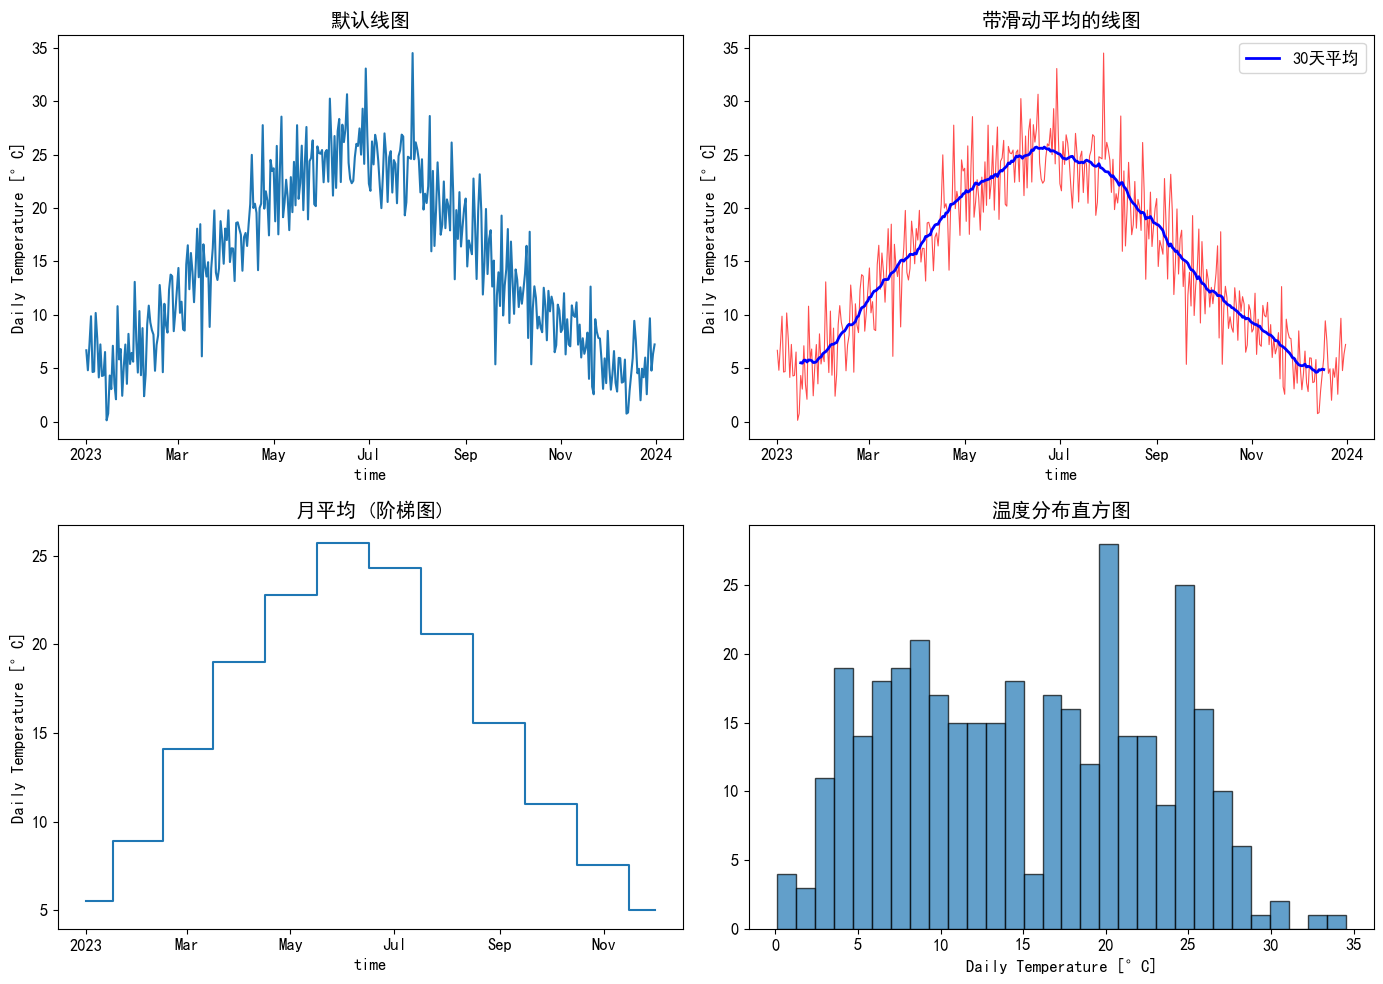

In [34]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
# 创建时间序列数据
np.random.seed(42)
time = pd.date_range('2023-01-01', '2023-12-31', freq='D')
temp = 15 + 10 * np.sin(2*np.pi*(np.arange(365)-80)/365) + np.random.randn(365)*3

ts = xr.DataArray(
    temp, dims='time',
    coords={'time': time},
    attrs={'units': '°C', 'long_name': 'Daily Temperature'}
)

# ===== 基本线图 =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 默认线图
ts.plot(ax=axes[0, 0])
axes[0, 0].set_title('默认线图')

# 自定义样式
ts.plot(ax=axes[0, 1], color='red', linewidth=0.8, alpha=0.7)
ts.rolling(time=30, center=True).mean().plot(
    ax=axes[0, 1], color='blue', linewidth=2, label='30天平均'
)
axes[0, 1].legend()
axes[0, 1].set_title('带滑动平均的线图')

# 月平均柱状图
monthly = ts.resample(time='MS').mean()
monthly.plot.step(ax=axes[1, 0], where='mid')
axes[1, 0].set_title('月平均 (阶梯图)')

# 直方图
ts.plot.hist(ax=axes[1, 1], bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('温度分布直方图')

plt.tight_layout()
plt.savefig('xarray_1d_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.2 二维数据绘图

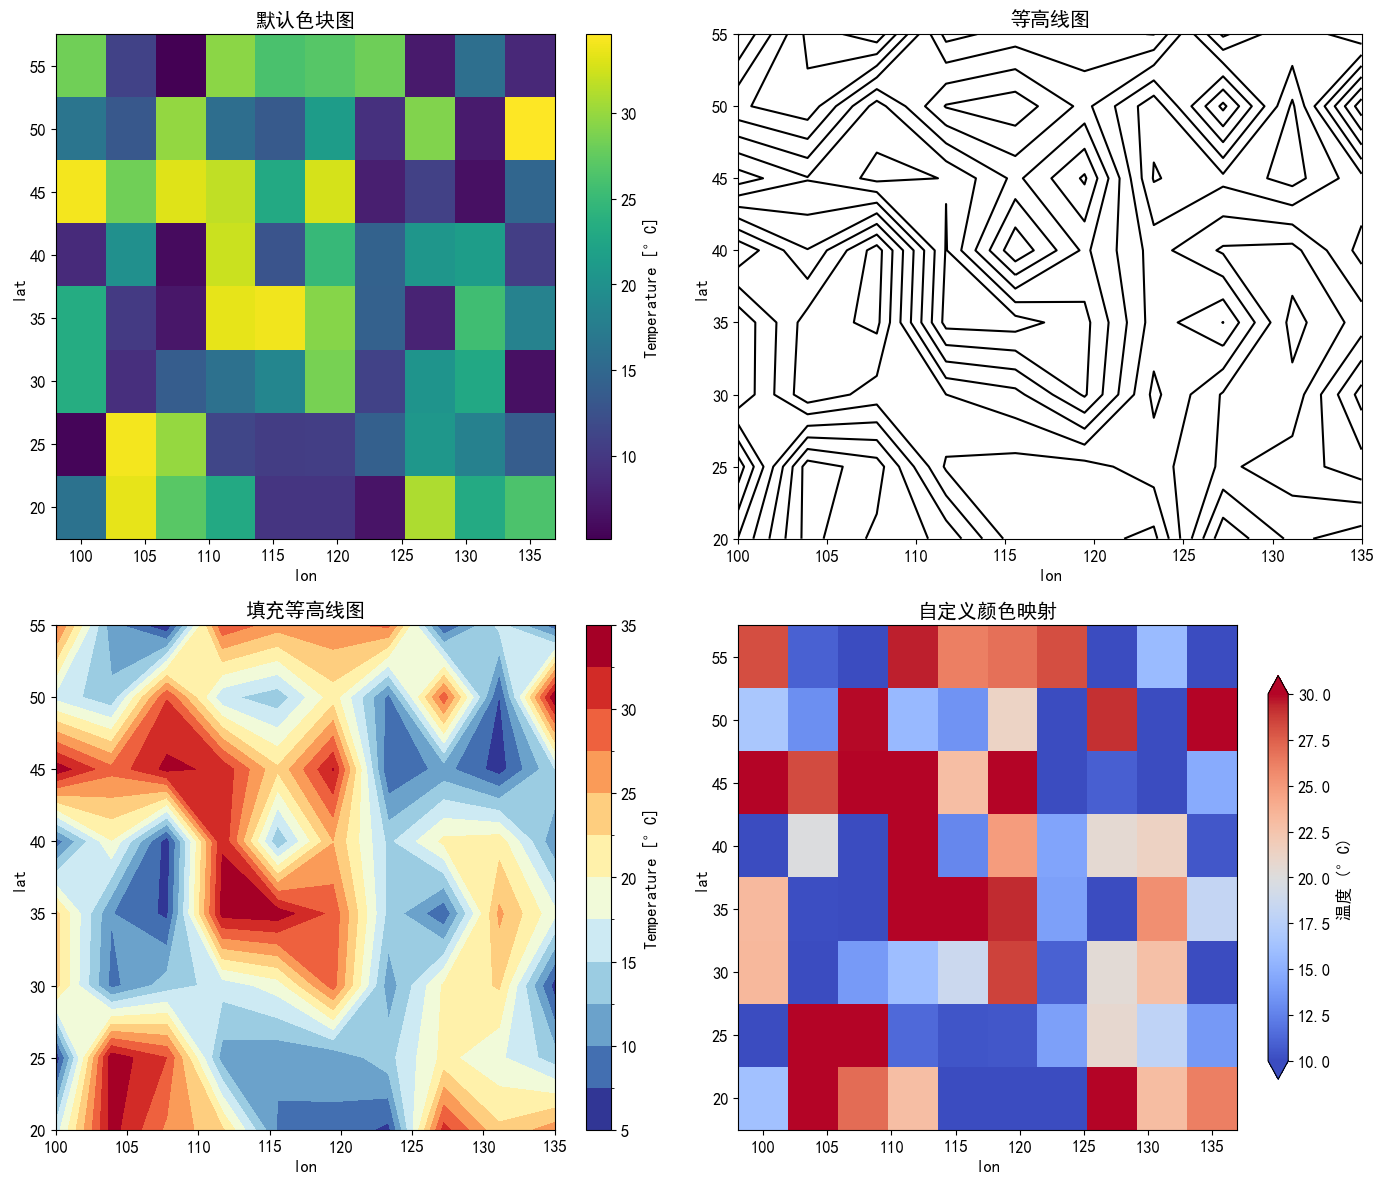

In [35]:
np.random.seed(42)
temp_2d = xr.DataArray(
    np.random.uniform(5, 35, (8, 10)),
    dims=['lat', 'lon'],
    coords={
        'lat': np.linspace(20, 55, 8),
        'lon': np.linspace(100, 135, 10)
    },
    attrs={'units': '°C', 'long_name': 'Temperature'}
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 默认色块图 (pcolormesh)
temp_2d.plot(ax=axes[0, 0])
axes[0, 0].set_title('默认色块图')

# 等高线图
temp_2d.plot.contour(ax=axes[0, 1], levels=10, colors='black')
axes[0, 1].set_title('等高线图')

# 填充等高线图
temp_2d.plot.contourf(ax=axes[1, 0], levels=15, cmap='RdYlBu_r')
axes[1, 0].set_title('填充等高线图')

# 自定义颜色映射
temp_2d.plot(
    ax=axes[1, 1],
    cmap='coolwarm',
    vmin=10, vmax=30,
    cbar_kwargs={'label': '温度 (°C)', 'shrink': 0.8}
)
axes[1, 1].set_title('自定义颜色映射')

plt.tight_layout()
plt.savefig('xarray_2d_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.3 FacetGrid —— 多面板绘图

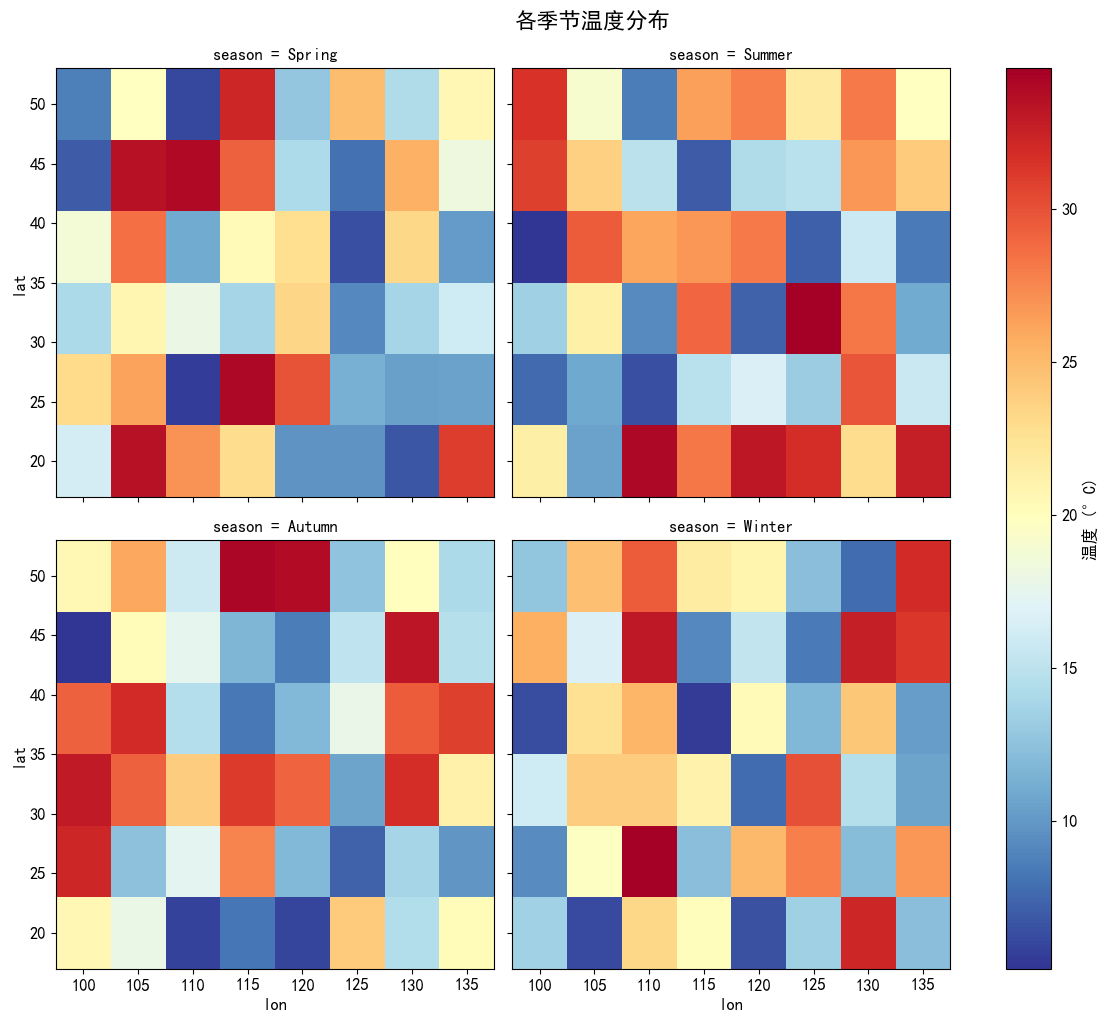

In [36]:
np.random.seed(42)
temp_seasonal = xr.DataArray(
    np.random.uniform(5, 35, (4, 6, 8)),
    dims=['season', 'lat', 'lon'],
    coords={
        'season': ['Spring', 'Summer', 'Autumn', 'Winter'],
        'lat': np.linspace(20, 50, 6),
        'lon': np.linspace(100, 135, 8)
    },
    attrs={'units': '°C', 'long_name': 'Temperature'}
)

# FacetGrid: 按维度自动创建多面板
fg = temp_seasonal.plot(
    col='season',        # 按season分列
    col_wrap=2,          # 每行2个
    cmap='RdYlBu_r',
    figsize=(12, 10),
    cbar_kwargs={'label': '温度 (°C)'}
)

plt.suptitle('各季节温度分布', y=1.02, fontsize=16)
plt.savefig('xarray_facet.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.4 Dataset 绘图

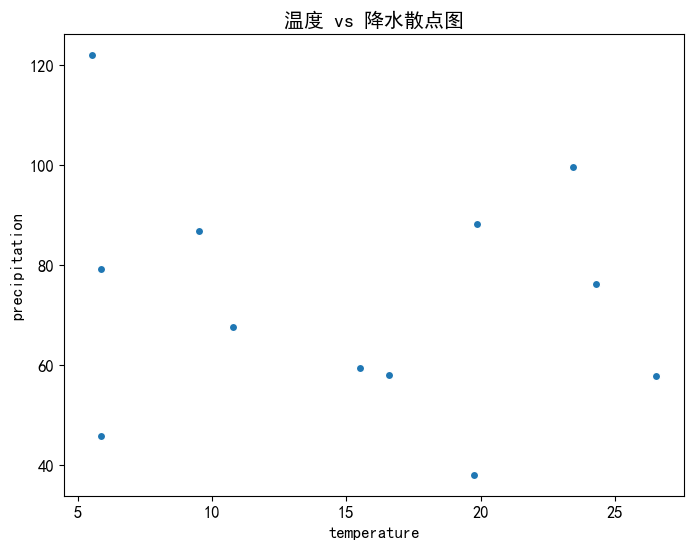

In [37]:
np.random.seed(42)
ds_plot = xr.Dataset({
    'temperature': (['time'], 15 + 10*np.sin(2*np.pi*np.arange(12)/12) + np.random.randn(12)),
    'precipitation': (['time'], np.random.uniform(20, 150, 12)),
}, coords={
    'time': pd.date_range('2023-01', periods=12, freq='MS'),
})

# Dataset 可以用散点图显示变量关系
fig, ax = plt.subplots(figsize=(8, 6))
ds_plot.plot.scatter(x='temperature', y='precipitation', ax=ax)
ax.set_title('温度 vs 降水散点图')
plt.savefig('xarray_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 12. 实战案例：气象数据分析

### 12.1 案例：模拟全年气温数据分析

数据集概览:
<xarray.Dataset> Size: 8MB
Dimensions:        (time: 1096, lat: 19, lon: 24)
Coordinates:
  * time           (time) datetime64[us] 9kB 2020-01-01 ... 2022-12-31
  * lat            (lat) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90
  * lon            (lon) int64 192B 0 15 30 45 60 75 ... 270 285 300 315 330 345
Data variables:
    temperature    (time, lat, lon) float64 4MB 16.27 14.36 ... -10.12 -8.044
    precipitation  (time, lat, lon) float64 4MB 3.753 15.44 ... 21.15 6.541
Attributes:
    title:    模拟全球气温降水数据集
    source:   Xarray教学模拟数据
    history:  Created on 2026-06-04 20:47:57.588024

数据大小: 8.0 MB

基本统计:
温度范围: -15.7 ~ 55.9 °C
温度均值: 23.0 °C
降水均值: 50.1 mm/day

月气候态:
<xarray.Dataset> Size: 88kB
Dimensions:        (month: 12, lat: 19, lon: 24)
Coordinates:
  * month          (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat            (lat) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90
  * lon            (lon) int64 192B 0 15 30 45 60 75 ... 270 285 300 3

C:\Users\xyt55\AppData\Local\Temp\ipykernel_66364\220079166.py:110: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"\n中国区域数据形状: {dict(china.dims)}")


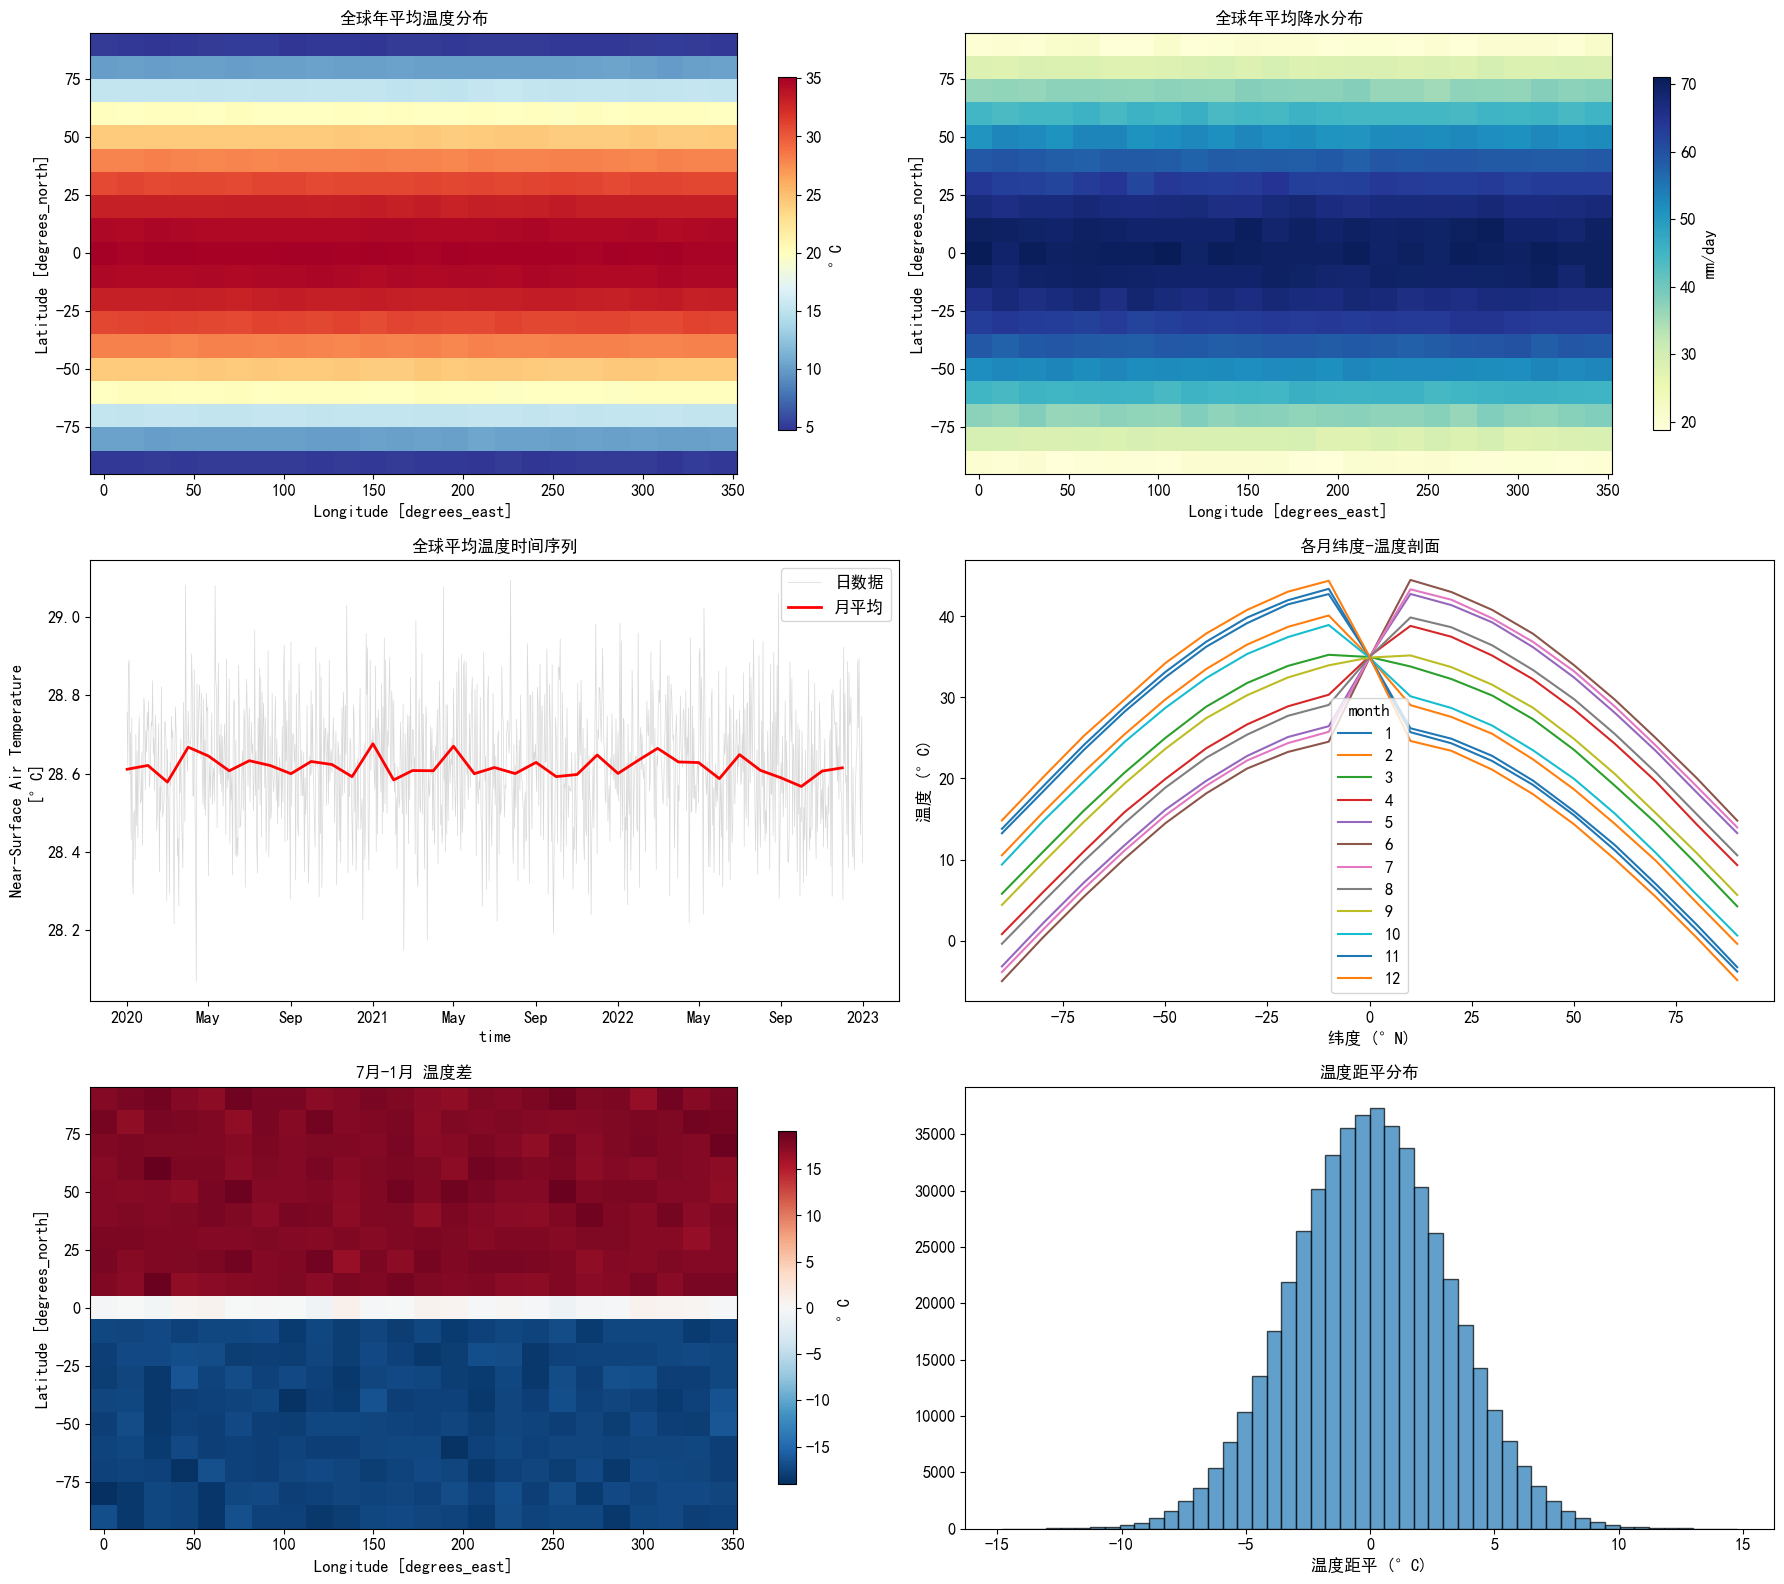

ValueError: unexpected encoding for scipy backend: ['zlib', 'complevel']

In [38]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12

# ============================================
# 步骤1: 创建模拟的全球气温数据集
# ============================================
np.random.seed(42)

# 定义坐标
time = pd.date_range('2020-01-01', '2022-12-31', freq='D')
lat = np.arange(-90, 91, 10)    # -90到90度，步长10
lon = np.arange(0, 360, 15)     # 0到345度，步长15

# 生成模拟温度场
# 温度 = 基准 + 纬度效应 + 季节效应 + 随机噪声
nt, nlat, nlon = len(time), len(lat), len(lon)

# 纬度效应: 赤道热，极地冷
lat_effect = 30 * np.cos(np.deg2rad(lat))  # (nlat,)

# 季节效应: 北半球7月最热，南半球1月最热
day_of_year = time.dayofyear.values
seasonal = 10 * np.sin(2 * np.pi * (day_of_year[:, None] - 80) / 365) * np.sign(lat[None, :])

# 组合
temp_base = lat_effect[None, :, None] + seasonal[:, :, None]
temp_noise = np.random.randn(nt, nlat, nlon) * 3
temperature = temp_base + temp_noise + 5  # 加上全球基准温度

# 生成模拟降水
precipitation = np.maximum(0, 
    50 * np.cos(np.deg2rad(lat))[None, :, None] + 
    np.random.exponential(20, (nt, nlat, nlon))
)

# 创建Dataset
ds = xr.Dataset(
    data_vars={
        'temperature': (['time', 'lat', 'lon'], temperature,
                       {'units': '°C', 'long_name': 'Near-Surface Air Temperature'}),
        'precipitation': (['time', 'lat', 'lon'], precipitation,
                         {'units': 'mm/day', 'long_name': 'Daily Precipitation'}),
    },
    coords={
        'time': time,
        'lat': ('lat', lat, {'units': 'degrees_north', 'long_name': 'Latitude'}),
        'lon': ('lon', lon, {'units': 'degrees_east', 'long_name': 'Longitude'}),
    },
    attrs={
        'title': '模拟全球气温降水数据集',
        'source': 'Xarray教学模拟数据',
        'history': f'Created on {pd.Timestamp.now()}'
    }
)

print("=" * 60)
print("数据集概览:")
print("=" * 60)
print(ds)
print(f"\n数据大小: {ds.nbytes / 1e6:.1f} MB")

# ============================================
# 步骤2: 基本数据探索
# ============================================
print("\n" + "=" * 60)
print("基本统计:")
print("=" * 60)
print(f"温度范围: {float(ds.temperature.min()):.1f} ~ {float(ds.temperature.max()):.1f} °C")
print(f"温度均值: {float(ds.temperature.mean()):.1f} °C")
print(f"降水均值: {float(ds.precipitation.mean()):.1f} mm/day")

# ============================================
# 步骤3: 计算气候态（多年平均）
# ============================================
# 计算月气候态
climatology = ds.groupby('time.month').mean(dim='time')
print("\n月气候态:")
print(climatology)

# ============================================
# 步骤4: 计算距平 (异常值)
# ============================================
anomaly = ds.groupby('time.month') - climatology
print("\n温度距平统计:")
print(f"  均值: {float(anomaly.temperature.mean()):.4f} °C (应接近0)")
print(f"  标准差: {float(anomaly.temperature.std()):.2f} °C")

# ============================================
# 步骤5: 纬度加权的全球平均
# ============================================
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"

# 全球平均温度时间序列
global_mean_temp = ds.temperature.weighted(weights).mean(dim=['lat', 'lon'])

# 月平均
global_monthly = global_mean_temp.resample(time='MS').mean()

# ============================================
# 步骤6: 区域选择与分析
# ============================================
# 选择中国区域 (大致范围)
china = ds.sel(lat=slice(15, 55), lon=slice(75, 135))
print(f"\n中国区域数据形状: {dict(china.dims)}")

# 中国区域年平均温度
china_annual_mean = china.temperature.mean(dim=['lat', 'lon']).resample(time='YS').mean()
print("中国区域年平均温度:")
print(china_annual_mean)

# ============================================
# 步骤7: 综合可视化
# ============================================
fig = plt.figure(figsize=(18, 16))

# 图1: 全球年平均温度分布
ax1 = fig.add_subplot(3, 2, 1)
ds.temperature.mean(dim='time').plot(
    ax=ax1, cmap='RdYlBu_r',
    cbar_kwargs={'label': '°C', 'shrink': 0.8}
)
ax1.set_title('全球年平均温度分布', fontsize=12)

# 图2: 全球年平均降水分布
ax2 = fig.add_subplot(3, 2, 2)
ds.precipitation.mean(dim='time').plot(
    ax=ax2, cmap='YlGnBu',
    cbar_kwargs={'label': 'mm/day', 'shrink': 0.8}
)
ax2.set_title('全球年平均降水分布', fontsize=12)

# 图3: 全球平均温度时间序列
ax3 = fig.add_subplot(3, 2, 3)
global_mean_temp.plot(ax=ax3, alpha=0.3, color='gray', linewidth=0.5, label='日数据')
global_monthly.plot(ax=ax3, color='red', linewidth=2, label='月平均')
ax3.set_title('全球平均温度时间序列', fontsize=12)
ax3.legend()

# 图4: 温度纬度剖面（按月）
ax4 = fig.add_subplot(3, 2, 4)
zonal_monthly = climatology.temperature.mean(dim='lon')
zonal_monthly.plot(
    ax=ax4, x='lat', hue='month',
    add_legend=True
)
ax4.set_title('各月纬度-温度剖面', fontsize=12)
ax4.set_xlabel('纬度 (°N)')
ax4.set_ylabel('温度 (°C)')

# 图5: 1月 vs 7月 温度对比
ax5 = fig.add_subplot(3, 2, 5)
jan_mean = ds.temperature.sel(time=ds.time.dt.month == 1).mean(dim='time')
jul_mean = ds.temperature.sel(time=ds.time.dt.month == 7).mean(dim='time')
diff = jul_mean - jan_mean
diff.plot(ax=ax5, cmap='RdBu_r', center=0,
          cbar_kwargs={'label': '°C', 'shrink': 0.8})
ax5.set_title('7月-1月 温度差', fontsize=12)

# 图6: 温度距平直方图
ax6 = fig.add_subplot(3, 2, 6)
anomaly.temperature.values.flatten()[::100]  # 采样避免过大
anomaly.temperature.plot.hist(
    ax=ax6, bins=50, edgecolor='black', alpha=0.7
)
ax6.set_title('温度距平分布', fontsize=12)
ax6.set_xlabel('温度距平 (°C)')

plt.tight_layout()
plt.savefig('climate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 步骤8: 保存结果
# ============================================
# 保存气候态
climatology.to_netcdf('climatology.nc', encoding={
    'temperature': {'dtype': 'float32', 'zlib': True, 'complevel': 5},
    'precipitation': {'dtype': 'float32', 'zlib': True, 'complevel': 5},
})
print("\n气候态数据已保存到 climatology.nc")

# 保存距平
anomaly.to_netcdf('anomaly.nc', encoding={
    'temperature': {'dtype': 'float32', 'zlib': True, 'complevel': 5},
    'precipitation': {'dtype': 'float32', 'zlib': True, 'complevel': 5},
})
print("距平数据已保存到 anomaly.nc")

print("\n分析完成！")

### 12.2 案例：与 Dask 配合处理大数据

In [39]:
# ============================================
# 使用 Dask 后端处理超大数据集
# ============================================

# Dask 允许延迟计算和分块处理，适合内存放不下的数据

# 创建分块数据集
ds_chunked = xr.Dataset({
    'temperature': xr.DataArray(
        # 使用 dask 数组
        data=np.random.randn(365*10, 180, 360),  # 10年日数据
        dims=['time', 'lat', 'lon'],
        coords={
            'time': pd.date_range('2010-01-01', periods=365*10, freq='D'),
            'lat': np.arange(-89.5, 90.5, 1),
            'lon': np.arange(0.5, 360.5, 1),
        }
    )
}).chunk({
    'time': 365,  # 按年分块
    'lat': 45,    # 纬度方向分块
    'lon': 90     # 经度方向分块
})

print("分块数据集:")
print(ds_chunked)
print(f"\n分块信息: {ds_chunked.chunks}")
print(f"内存占用: {ds_chunked.nbytes / 1e9:.1f} GB (未计算)")

# Dask 延迟计算 - 只定义计算图，不实际执行
mean_temp = ds_chunked.temperature.mean(dim='time')
print(f"\n均值 (延迟计算): {mean_temp}")

# .compute() 时才实际执行
# result = mean_temp.compute()
# print(f"计算结果形状: {result.shape}")

ImportError: chunk manager 'dask' is not available. Please make sure 'dask' is installed and importable.

---

## 13. 总结与进阶资源

### 13.1 核心知识点回顾

```
Xarray 知识体系
│
├── 数据结构
│   ├── DataArray: 带标签的N维数组
│   └── Dataset: DataArray的字典集合
│
├── 数据创建
│   ├── 从NumPy数组创建
│   ├── 从文件读取 (NetCDF, Zarr等)
│   └── 从Pandas转换
│
├── 数据索引
│   ├── isel(): 基于位置
│   ├── sel(): 基于标签 ⭐
│   ├── where(): 布尔索引
│   └── method='nearest': 近似匹配
│
├── 数据计算
│   ├── 算术运算 (自动对齐+广播)
│   ├── 聚合统计 (mean, sum, std等)
│   ├── rolling(): 滚动窗口
│   ├── weighted(): 加权计算
│   └── apply_ufunc(): 自定义函数
│
├── 分组与重采样
│   ├── groupby(): 分组操作
│   └── resample(): 时间重采样
│
├── 数据整合
│   ├── concat(): 拼接
│   ├── merge(): 合并
│   ├── align(): 对齐
│   └── 缺失值处理
│
├── 文件IO
│   ├── NetCDF: to_netcdf() / open_dataset()
│   ├── Zarr: to_zarr() / open_zarr()
│   └── open_mfdataset(): 多文件读取
│
└── 可视化
    ├── .plot(): 自动选择合适的图类型
    ├── .plot.line/contour/contourf/hist/scatter
    └── FacetGrid: 多面板图
```

### 13.2 常见最佳实践

In [ ]:
# 1. 始终使用 sel() 而非位置索引
# ❌ data[0, :, 2]
# ✅ data.sel(time='2023-01', lon=120)

# 2. 保存有意义的属性
da.attrs['units'] = 'K'
da.attrs['long_name'] = 'Surface Temperature'

# 3. 处理大文件时使用分块
ds = xr.open_dataset('large_file.nc', chunks={'time': 100})

# 4. 写入文件时使用压缩
ds.to_netcdf('output.nc', encoding={
    'var': {'zlib': True, 'complevel': 5, 'dtype': 'float32'}
})

# 5. 使用 with 语句管理文件
with xr.open_dataset('data.nc') as ds:
    result = ds.temperature.mean()

### 13.3 进阶学习资源

| 资源 | 链接 |
|------|------|
| 📖 官方文档 | https://docs.xarray.dev/ |
| 📖 官方教程 | https://tutorial.xarray.dev/ |
| 🎓 Xarray Workshop | https://github.com/xarray-contrib/xarray-tutorial |
| 📦 Xarray 生态系统 | xgcm, xesmf, regionmask, cf-xarray 等 |
| 🌐 Pangeo 社区 | https://pangeo.io/ (大数据地球科学) |
| 💬 GitHub Discussions | https://github.com/pydata/xarray/discussions |

### 13.4 相关库推荐

```
xarray 生态系统:
├── xgcm         - 网格操作（有限体积）
├── xesmf        - 空间重网格化 (regridding)
├── regionmask   - 地理区域掩膜
├── cf-xarray    - CF约定支持
├── xskillscore  - 统计技能评分
├── climpred     - 气候预测验证
├── verde        - 空间插值
├── rioxarray    - 栅格IO (GeoTIFF等)
├── xoak         - 非结构化网格索引
└── flox         - 快速GroupBy
```

---

> **📝 课后练习建议：**
> 1. 下载一个真实的 NetCDF 气象数据文件（如 ERA5 或 NCEP 再分析资料），用 Xarray 读取并探索
> 2. 计算某个区域的季节平均气温和距平
> 3. 使用 `groupby` 和 `resample` 进行时间聚合分析
> 4. 绘制气候态空间分布图和时间序列图
> 5. 尝试使用 Dask 处理较大的数据集